# US Firm Characteristics - Strategy Analysis

This notebook converts the backtest registry for the US
firm-characteristics case study into a per-case-study strategy
assessment. Metrics are reported with block-bootstrap 95%
confidence interval, every comparison goes through
`backtest_paired_metrics`, and the holdout closure uses paired rather
than point-difference reasoning. Cross-case-study comparison is reserved
for Chapter 20.

**Learning objectives**

- Read uncertainty-aware backtest metrics (Sharpe with CI, PSR, DSR) from
  the registry rather than transcribing point estimates.
- Resolve the one sealed holdout by the validation carrier's complete
  strategy specification rather than selecting on holdout performance.
- Quantify implementation friction with a micro-cap-realistic extended
  cost grid driven by the illiquidity profile of selected stocks.
- Distinguish a `straddles_zero` decay (CI includes 0 but is wide because
  of a 12-period holdout) from `excludes_zero_strong` evidence.

**Book reference**: Chapter 20, §20.1 (the §9 handoff feeds Ch20's
cross-case-study aggregation).

**Prerequisites**: case-study pipeline through `14_risk_management`; the
locked registry (`case_studies/us_firm_characteristics/run_log/registry.db`).

**Scope**: no training or re-backtesting. The case-study pipeline registers
the derived paired-metrics rows before this notebook runs, after which the
analysis is registry-read only.

In [1]:
"""US Firm Characteristics - Strategy Analysis."""

import datetime as _dt
import json
import sqlite3
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch  # ml4t.diagnostic loads cudart; torch must import first
import yaml
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

In [2]:
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_run_artifacts,
)
from ml4t.diagnostic.visualization.backtest.tail_risk import plot_tail_risk_analysis
from ml4t.diagnostic.visualization.portfolio.drawdown_plots import (
    plot_drawdown_underwater,
)
from ml4t.diagnostic.visualization.portfolio.returns_plots import (
    plot_annual_returns_bar,
    plot_cumulative_returns,
    plot_monthly_returns_heatmap,
    plot_returns_distribution,
)
from ml4t.diagnostic.visualization.portfolio.risk_plots import plot_rolling_sharpe

In [3]:
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.benchmark import load_benchmark_metrics, load_benchmark_returns
from case_studies.utils.external_benchmarks import (
    align_to_strategy as align_external_benchmark,
)
from case_studies.utils.external_benchmarks import (
    align_to_strategy_monthly as align_external_benchmark_monthly,
)
from case_studies.utils.external_benchmarks import (
    compute_benchmark_diagnostics,
    compute_subperiod_diagnostics,
    load_ff_market_returns,
)

In [4]:
from case_studies.utils.factor_attribution import (
    compute_bootstrap_ci,
    compute_rolling_exposures,
    load_factor_data,
    plot_attribution_waterfall,
    plot_rolling_exposures,
    run_factor_regression,
    run_placebo_benchmark,
)
from case_studies.utils.registry import (
    load_backtest_fold_metrics,
    load_backtest_metrics,
    load_paired_metrics,
)
from case_studies.utils.strategy_analysis import (
    ci_status,
    fmt_gate,
    gate1_validation_sharpe_geq_zero,
    gate2_holdout_diff_not_excludes_zero_negatively,
    plot_concentration_curve,
    plot_cost_decay,
    plot_ic_vs_sharpe,
    rank_backtests_on_common_support,
    resolve_canonical_rank1_lineage,
    select_holdout_self_backtest,
)
from utils.paths import display_path, get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title, ml4t_diverging

In [5]:
MAX_SYMBOLS = 0
SEED = 42

In [6]:
CASE_STUDY = "us_firm_characteristics"
PRIMARY_LABEL = "fwd_ret_1m"  # setup.yaml primary; benchmark series keyed here
PERIODS_PER_YEAR = 12  # monthly cadence
CASE_DIR = get_case_study_dir(CASE_STUDY)
OUTPUT_DIR = get_output_dir(20, CASE_STUDY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
set_global_seeds(SEED)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

explorer = BacktestExplorer(CASE_STUDY)
print(explorer)

BacktestExplorer('us_firm_characteristics', 2536 runs: allocation=1360, cost_sensitivity=11, holdout=1, signal=1164)


Compact formatters keep unavailable registry values explicit in the
reader-facing tables.

In [7]:
def _fmt_ci(point: float | None, lo: float | None, hi: float | None, fmt: str = ".3f") -> str:
    """Compact `point [lo, hi]` formatter with NULL-safety."""
    if point is None:
        return "-"
    p = format(point, fmt)
    if lo is None or hi is None:
        return f"{p} [-, -]"
    return f"{p} [{format(lo, fmt)}, {format(hi, fmt)}]"

In [8]:
def _fmt(val: float | None, fmt: str = ".4f") -> str:
    return "-" if val is None else format(val, fmt)

## §1 Handoff from model analysis

The strategy phase inherits a single rank-1 model from
`10_model_analysis.py` §8. The selected backtest trains on the
**winsorized continuous return label** `fwd_ret_1m_win` rather than the
setup-primary `fwd_ret_1m` - the registry's rank-1 by validation Sharpe
emerges from the variant. The winsorization clips the upper and lower
1% of cross-sectional monthly returns, dampening the influence of
extreme firm-month observations on the regression target. IC on the
prediction set is computed on continuous model scores against continuous
(un-winsorized) realized returns. The setup primary `fwd_ret_1m` remains
the canonical EW benchmark and the prose-reference label.

In [9]:
# The shared resolver applies the v3.0 common-support contract whenever
# corrected conformal rows are present. Validation chooses the carrier once;
# the sealed holdout does not participate in this ranking.
rank1 = resolve_canonical_rank1_lineage(CASE_STUDY)
TOP_HASH = rank1["val_backtest_hash"]
TOP_PHASH = rank1["val_prediction_hash"]
RANK1_STAGE = rank1["val_stage"]
RANK1_FAMILY = rank1["family"]
RANK1_CONFIG = rank1["config_name"]
RANK1_LABEL = rank1["label"]
COMMON_SUPPORT_SHARPE = rank1["val_sharpe"]
COMMON_SUPPORT_N = rank1["comparison_n_periods"]
COMMON_SUPPORT_START = rank1["comparison_start"]
COMMON_SUPPORT_END = rank1["comparison_end"]

Registry metadata anchors the selected carrier and its prediction-side IC
to the exact validation hashes used downstream.

In [10]:
_db = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(str(_db)) as _con:
    _row = _con.execute(
        "SELECT ic_mean_daily, ic_ci_lo, ic_ci_hi, ic_t_hac, ic_p_hac, ic_n_days, "
        "ic_hac_lag, ic_pct_positive "
        "FROM prediction_metrics WHERE prediction_hash = ?",
        (TOP_PHASH,),
    ).fetchone()

Selection-bias statistics come from the family cohort that contains the
selected validation carrier.

In [11]:
with sqlite3.connect(str(_db)) as _con:
    _cohort_row = _con.execute(
        "SELECT k_variants, dsr_raw, dsr_raw_pvalue, dsr_mp, dsr_mp_pvalue, "
        "dsr_er, dsr_er_pvalue, expected_max_sharpe_raw, "
        "expected_max_sharpe_mp, expected_max_sharpe_er, min_trl_periods_raw, "
        "min_trl_periods_mp, min_trl_periods_er, pbo, pbo_n_combinations, "
        "pbo_n_folds, leader_hash, leader_sharpe "
        "FROM cohort_metrics "
        "WHERE cohort_type='family' AND stage=? AND label=? AND family=?",
        (RANK1_STAGE, RANK1_LABEL, RANK1_FAMILY),
    ).fetchone()

In [12]:
COHORT = (
    {
        "k_variants": _cohort_row[0],
        "dsr_raw": _cohort_row[1],
        "dsr_raw_pvalue": _cohort_row[2],
        "dsr_mp": _cohort_row[3],
        "dsr_mp_pvalue": _cohort_row[4],
        "dsr_er": _cohort_row[5],
        "dsr_er_pvalue": _cohort_row[6],
        "expected_max_sharpe_raw": _cohort_row[7],
        "expected_max_sharpe_mp": _cohort_row[8],
        "expected_max_sharpe_er": _cohort_row[9],
        "min_trl_periods_raw": _cohort_row[10],
        "min_trl_periods_mp": _cohort_row[11],
        "min_trl_periods_er": _cohort_row[12],
        "pbo": _cohort_row[13],
        "pbo_n_combinations": _cohort_row[14],
        "pbo_n_folds": _cohort_row[15],
        "leader_hash": _cohort_row[16],
        "leader_sharpe": _cohort_row[17],
    }
    if _cohort_row is not None
    else None
)

In [13]:
ic_mean, ic_lo, ic_hi, ic_t, ic_p, ic_ndays, ic_lag, ic_pct = _row

print(f"Rank-1: family={RANK1_FAMILY}, config={RANK1_CONFIG}, label={RANK1_LABEL}")
print(f"        prediction_hash={TOP_PHASH}, backtest_hash={TOP_HASH}")
print(
    f"        common-support Sharpe={COMMON_SUPPORT_SHARPE:.4f}, "
    f"n={COMMON_SUPPORT_N}, {COMMON_SUPPORT_START:%Y-%m-%d} to {COMMON_SUPPORT_END:%Y-%m-%d}"
)
print(
    f"        setup-primary label={PRIMARY_LABEL}; comparisons follow rank-1 label={RANK1_LABEL}."
)
print()
print("Per-decision-time IC (validation, continuous score vs continuous returns):")
print(f"  IC = {_fmt_ci(ic_mean, ic_lo, ic_hi, '.4f')}  (HAC, lag={int(ic_lag)})")
print(f"  t_HAC = {ic_t:.3f}, p_HAC = {ic_p:.3e}")
print(f"  n_days = {int(ic_ndays)}, pct_positive = {ic_pct:.1%}")
print(f"  CI status: {ci_status(ic_lo, ic_hi)}")

Rank-1: family=gbm, config=default_huber, label=fwd_ret_1m_win
        prediction_hash=00b50224c546, backtest_hash=b43559d60839
        common-support Sharpe=2.9611, n=99, 2007-10-31 to 2015-12-31
        setup-primary label=fwd_ret_1m; comparisons follow rank-1 label=fwd_ret_1m_win.

Per-decision-time IC (validation, continuous score vs continuous returns):
  IC = 0.0405 [0.0289, 0.0521]  (HAC, lag=4)
  t_HAC = 6.937, p_HAC = 2.992e-10
  n_days = 110, pct_positive = 79.1%
  CI status: excludes_zero_strong


The holdout resolver requires an exact strategy-specification match. This
preserves the one-holdout rule and prevents an allocator from winning by
holdout performance.

In [14]:
HO_HASH = select_holdout_self_backtest(CASE_STUDY, TOP_HASH)
if HO_HASH is None:
    raise RuntimeError("No strict-lineage holdout matches the validation rank-1 carrier.")
if rank1["holdout_backtest_hash"] != HO_HASH:
    raise RuntimeError("Canonical resolver and exact-spec holdout lookup disagree.")

with sqlite3.connect(str(_db)) as _con:
    _holdout_meta = _con.execute(
        "SELECT p.training_hash, t.family, t.config_name, t.label, pm.ic_mean_daily "
        "FROM backtest_runs b "
        "JOIN prediction_sets p ON b.prediction_hash=p.prediction_hash "
        "JOIN training_runs t ON p.training_hash=t.training_hash "
        "JOIN prediction_metrics pm ON p.prediction_hash=pm.prediction_hash "
        "WHERE b.backtest_hash=? AND p.split='holdout'",
        (HO_HASH,),
    ).fetchone()
_HO_TRAINING_HASH, HO_FAMILY, HO_CONFIG, HO_LABEL, HO_IC = _holdout_meta

The publication registry is complete before this analysis runs. The two
derived holdout comparisons must already exist and the validation comparison
must name the frozen carrier exactly.

In [15]:
with sqlite3.connect(str(_db)) as _con:
    _holdout_pairs = _con.execute(
        "SELECT benchmark_kind, benchmark_hash FROM backtest_paired_metrics "
        "WHERE challenger_hash=? AND benchmark_kind IN "
        "('val_rank1_self', 'equal_weight_holdout_side_artifact')",
        (HO_HASH,),
    ).fetchall()
_pair_map = {kind: benchmark_hash for kind, benchmark_hash in _holdout_pairs}
if set(_pair_map) != {"val_rank1_self", "equal_weight_holdout_side_artifact"}:
    raise RuntimeError(f"Incomplete holdout closure pairs: {_pair_map}")
if _pair_map["val_rank1_self"] != TOP_HASH:
    raise RuntimeError("Holdout decay is not paired against the frozen validation carrier.")

In [16]:
print(
    f"Strict-lineage holdout: {HO_FAMILY}/{HO_CONFIG}, label={HO_LABEL}, "
    f"backtest_hash={HO_HASH}, IC={HO_IC:.4f}"
)

Strict-lineage holdout: gbm/default_huber, label=fwd_ret_1m_win, backtest_hash=3d39bbd68481, IC=0.0610


The IC table above reads as a continuous-score-vs-continuous-return
signal: HAC-adjusted CI status indicates whether the prediction edge
is `excludes_zero_strong` on the positive side. The strategy-side
translation of the prediction-stage IC depends critically on
cross-sectional concentration (top-K decile from ~2,500 stocks); §3
reports the selection-adjusted Sharpe under the sweep's k-variants
search.

**Kill conditions** are not encoded in `setup.yaml` for this CS. The
notebook evaluates two universal gates in §9: (i) the validation Sharpe
CI lower bound ≥ 0, and (ii) the holdout strategy-vs-EW paired CI does
not exclude zero on the negative side. Both are reported as
pass / partial / fail without verdict labels.

## §2 Search context, family comparison, and lineage waterfall

The equal-weight baseline covers the full family x config x label grid.
The search-context table below summarizes the
distribution; the family-level breakdown then locates where the
rank-1's edge comes from within the sweep.

In [17]:
ctx = explorer.search_context("signal")
search_table = pl.DataFrame(
    [
        {"metric": "Total baseline backtests", "value": f"{ctx['total']:,}"},
        {"metric": "Mean Sharpe", "value": f"{ctx['mean_sharpe']:.3f}"},
        {"metric": "Median Sharpe", "value": f"{ctx['median_sharpe']:.3f}"},
        {"metric": "P90 Sharpe", "value": f"{ctx['p90_sharpe']:.3f}"},
        {"metric": "% positive Sharpe", "value": f"{ctx['pct_positive']:.1f}%"},
        {"metric": "Top-by-Sharpe in this sweep", "value": f"{ctx['champion_sharpe']:.3f}"},
        {"metric": "Top-by-Sharpe percentile", "value": f"{ctx['champion_percentile']:.1f}%"},
    ]
)
print("Equal-weight baseline search context:")
print(search_table)

Equal-weight baseline search context:
shape: (7, 2)
┌─────────────────────────────┬────────┐
│ metric                      ┆ value  │
│ ---                         ┆ ---    │
│ str                         ┆ str    │
╞═════════════════════════════╪════════╡
│ Total baseline backtests    ┆ 1,164  │
│ Mean Sharpe                 ┆ 1.094  │
│ Median Sharpe               ┆ 1.039  │
│ P90 Sharpe                  ┆ 2.184  │
│ % positive Sharpe           ┆ 95.8%  │
│ Top-by-Sharpe in this sweep ┆ 2.754  │
│ Top-by-Sharpe percentile    ┆ 100.0% │
└─────────────────────────────┴────────┘


In [18]:
with sqlite3.connect(str(_db)) as _con:
    _famdf = pl.DataFrame(
        _con.execute(
            """
            SELECT
                t.family,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi
            FROM backtest_metrics bm
            JOIN backtest_runs b ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t  ON p.training_hash = t.training_hash
            WHERE b.stage = 'signal'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=["family", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"],
        orient="row",
    )

family_summary = (
    _famdf.group_by("family")
    .agg(
        n=pl.len(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_q25=pl.col("sharpe").quantile(0.25),
        sharpe_q75=pl.col("sharpe").quantile(0.75),
        sharpe_max=pl.col("sharpe").max(),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100),
    )
    .sort("sharpe_median", descending=True)
)
print("Family-level equal-weight baseline Sharpe summary:")
print(family_summary)

Family-level equal-weight baseline Sharpe summary:
shape: (4, 7)
┌────────────────┬─────┬───────────────┬────────────┬────────────┬────────────┬──────────────┐
│ family         ┆ n   ┆ sharpe_median ┆ sharpe_q25 ┆ sharpe_q75 ┆ sharpe_max ┆ pct_positive │
│ ---            ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ str            ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞════════════════╪═════╪═══════════════╪════════════╪════════════╪════════════╪══════════════╡
│ gbm            ┆ 372 ┆ 1.797843      ┆ 1.484543   ┆ 2.315428   ┆ 2.754197   ┆ 100.0        │
│ tabular_dl     ┆ 240 ┆ 1.008906      ┆ 0.709113   ┆ 1.370083   ┆ 2.184198   ┆ 99.166667    │
│ linear         ┆ 372 ┆ 0.636208      ┆ 0.36528    ┆ 1.035121   ┆ 1.631036   ┆ 98.924731    │
│ latent_factors ┆ 180 ┆ 0.434001      ┆ 0.029726   ┆ 0.674114   ┆ 1.642064   ┆ 76.111111    │
└────────────────┴─────┴───────────────┴────────────┴────────────┴────────────┴─

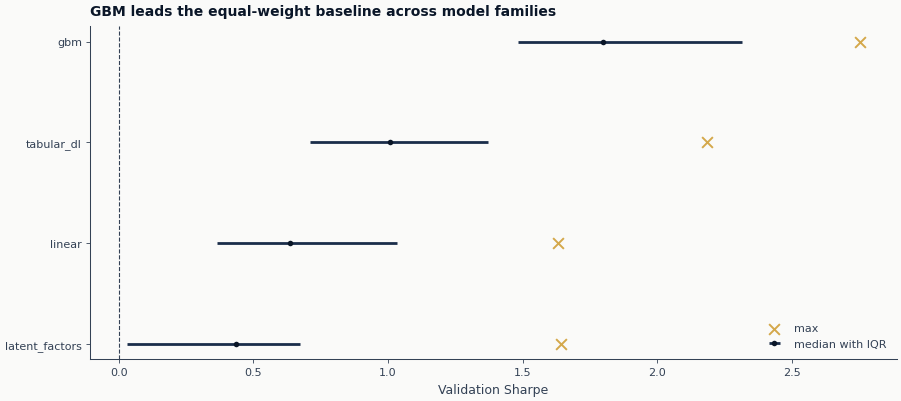

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
fams = family_summary["family"].to_list()
y = np.arange(len(fams))
medians = family_summary["sharpe_median"].to_numpy()
q25 = family_summary["sharpe_q25"].to_numpy()
q75 = family_summary["sharpe_q75"].to_numpy()
maxima = family_summary["sharpe_max"].to_numpy()

ax.errorbar(
    medians,
    y,
    xerr=[medians - q25, q75 - medians],
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    elinewidth=2.0,
    capsize=4,
    label="median with IQR",
)
ax.scatter(maxima, y, marker="x", color=COLORS["amber"], s=60, label="max", zorder=5)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(fams)
ax.set_xlabel("Validation Sharpe")
add_message_title(ax, "GBM leads the equal-weight baseline across model families")
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
fig.show()

Family medians span a range with the max-by-family markers locating each
family's best config. The equal-weight baseline's
positive-Sharpe rate (from the search-context table above) indicates
how broadly tradeable the cross-section is in this sweep; the rank-1
typically gets its edge as much from placement at a family's tail as
from a qualitative class advantage. The family-IQR overlap quantifies
how much of the rank-1's edge is family-driven vs config-tuning
driven.

In [20]:
# The carrier lineage records all stages registered against the selected
# prediction set. The schema value `signal` denotes the equal-weight baseline.
lineage = explorer.champion_lineage(TOP_PHASH)
ci_lo: dict[str, float] = {}
ci_hi: dict[str, float] = {}
for stage_name, info in lineage.items():
    bm = load_backtest_metrics(CASE_STUDY, backtest_hash=info["backtest_hash"])
    if not bm.is_empty():
        row = bm.row(0, named=True)
        ci_lo[stage_name] = row.get("sharpe_ci95_lo")
        ci_hi[stage_name] = row.get("sharpe_ci95_hi")

print("Lineage stages present for rank-1 prediction:")
for s, info in lineage.items():
    lo, hi = ci_lo.get(s), ci_hi.get(s)
    print(f"  {s}: hash={info['backtest_hash']}, Sharpe={_fmt_ci(info['sharpe'], lo, hi)}")

missing_stages = [s for s in ("allocation", "cost_sensitivity", "risk_overlay") if s not in lineage]
if missing_stages:
    print()
    print(f"Stage transitions not run for this prediction: {missing_stages}")
    print(
        "  (cost_sensitivity and risk_overlay sweeps exist in the registry but "
        "were registered against different prediction_hashes; cross-prediction "
        "stage transitions are Ch20's lane.)"
    )

Lineage stages present for rank-1 prediction:
  signal: hash=f76693e50d38, Sharpe=2.738 [2.236, 3.381]
  allocation: hash=5cbce3490c44, Sharpe=2.738 [2.236, 3.381]

Stage transitions not run for this prediction: ['cost_sensitivity', 'risk_overlay']
  (cost_sensitivity and risk_overlay sweeps exist in the registry but were registered against different prediction_hashes; cross-prediction stage transitions are Ch20's lane.)


The corrected conformal candidates start one fold later than the equal-weight
carrier. The comparison below therefore recomputes both alternatives on the
exact 99-month timestamp intersection rather than comparing their natural
registry windows.

In [21]:
with sqlite3.connect(str(_db)) as _con:
    strict_conformal_hashes = [
        row[0]
        for row in _con.execute(
            "SELECT b.backtest_hash FROM backtest_runs b "
            "JOIN backtest_metrics bm ON bm.backtest_hash=b.backtest_hash "
            "JOIN prediction_sets p ON p.prediction_hash=b.prediction_hash "
            "WHERE p.split='validation' AND bm.sharpe IS NOT NULL "
            "AND json_extract(b.spec_json, '$.strategy.allocation.method')="
            "'conformal_weighted' "
            "AND json_extract(b.spec_json, "
            "'$.strategy.allocation.calibration_version')='walk_forward_v2'"
        )
    ]
if not strict_conformal_hashes:
    raise RuntimeError("No walk_forward_v2 conformal candidate is registered.")

conformal_ranking = rank_backtests_on_common_support(
    CASE_STUDY,
    [TOP_HASH, *strict_conformal_hashes],
    periods_per_year=PERIODS_PER_YEAR,
)
best_conformal = conformal_ranking.filter(pl.col("backtest_hash") != TOP_HASH).row(0, named=True)
BEST_CONFORMAL_HASH = best_conformal["backtest_hash"]
selection_comparison = conformal_ranking.filter(
    pl.col("backtest_hash").is_in([TOP_HASH, BEST_CONFORMAL_HASH])
).with_columns(
    pl.when(pl.col("backtest_hash") == TOP_HASH)
    .then(pl.lit("Equal-weight carrier"))
    .otherwise(pl.lit("Best corrected conformal"))
    .alias("method")
)
if selection_comparison["n_periods"].n_unique() != 1:
    raise RuntimeError("Selection comparison does not have identical period support.")
print("Common-support allocation comparison:")
print(selection_comparison.select("method", "backtest_hash", "sharpe", "n_periods", "start", "end"))

Common-support allocation comparison:
shape: (2, 6)
┌────────────────┬───────────────┬──────────┬───────────┬───────────────┬─────────────────────┐
│ method         ┆ backtest_hash ┆ sharpe   ┆ n_periods ┆ start         ┆ end                 │
│ ---            ┆ ---           ┆ ---      ┆ ---       ┆ ---           ┆ ---                 │
│ str            ┆ str           ┆ f64      ┆ i64       ┆ datetime[μs]  ┆ datetime[μs]        │
╞════════════════╪═══════════════╪══════════╪═══════════╪═══════════════╪═════════════════════╡
│ Equal-weight   ┆ b43559d60839  ┆ 2.961068 ┆ 99        ┆ 2007-10-31    ┆ 2015-12-31 00:00:00 │
│ carrier        ┆               ┆          ┆           ┆ 00:00:00      ┆                     │
│ Best corrected ┆ 9707eddaf43e  ┆ 2.95539  ┆ 99        ┆ 2007-10-31    ┆ 2015-12-31 00:00:00 │
│ conformal      ┆               ┆          ┆           ┆ 00:00:00      ┆                     │
└────────────────┴───────────────┴──────────┴───────────┴───────────────┴───────────

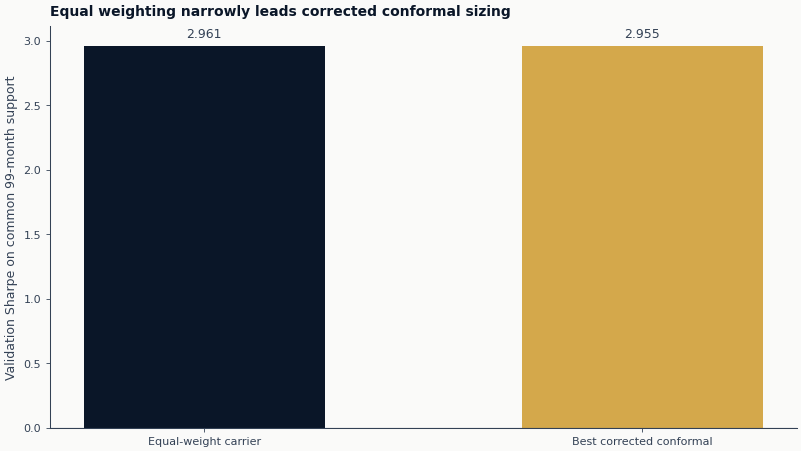

In [22]:
stage_labels = selection_comparison["method"].to_list()
stage_values = selection_comparison["sharpe"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
x = np.arange(len(stage_labels))
bars = ax.bar(
    x,
    stage_values,
    color=[COLORS["blue"], COLORS["amber"]],
    width=0.55,
)
ax.bar_label(bars, labels=[f"{value:.3f}" for value in stage_values], padding=4)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xticks(x, stage_labels)
ax.set_ylabel("Validation Sharpe on common 99-month support")
add_message_title(ax, "Equal weighting narrowly leads corrected conformal sizing")
fig.show()

The common-support comparison makes the calibration cost visible: corrected
conformal sizing reaches Sharpe 2.955, just below the equal-weight carrier's
2.961 over the same 99 months. The difference is too small to support an
allocation claim, so the simpler equal-weight carrier remains rank-1. §5
reads the cost-sensitivity sweep as a friction floor across the broader
allocation cohort rather than as a transition on this exact lineage.

## §3 Headline performance with uncertainty

The rank-1 specification is chosen on the common comparison window. The
metric table then reports the carrier's complete 110-month validation record
with block-bootstrap 95% CIs from `backtest_metrics`; the equity overlay
shows that full trajectory against the equal-weight universe benchmark. The
bootstrap block captures serial dependence and need not match the one-month
rebalance step.

In [23]:
full = load_backtest_metrics(CASE_STUDY, backtest_hash=TOP_HASH).row(0, named=True)

with sqlite3.connect(str(_db)) as _con:
    top_spec = json.loads(
        _con.execute(
            "SELECT spec_json FROM backtest_runs WHERE backtest_hash=?",
            (TOP_HASH,),
        ).fetchone()[0]
    )
top_strategy = top_spec["strategy"]
top_signal = top_strategy["signal"]
top_allocation = top_strategy.get("allocation") or {}

spec_block = {
    "case_study": CASE_STUDY,
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": RANK1_LABEL,
    "setup_primary_label": PRIMARY_LABEL,
    "signal_method": top_signal.get("method"),
    "allocator": top_allocation.get("method", "equal_weight"),
    "top_k": top_signal.get("top_k"),
    "rebalance_step": setup["labels"]["rebalance_step"][RANK1_LABEL],
    "cost_assumption": "stage-dependent; §5 reports the cost sensitivity curve",
    "cross_stage_rank1_stage": RANK1_STAGE,
    "selection_sharpe_common_support": COMMON_SUPPORT_SHARPE,
    "selection_window_periods": COMMON_SUPPORT_N,
    "full_validation_sharpe": full["sharpe"],
    "full_validation_periods": int(full["n_periods"]),
    "num_trades": int(full["num_trades"]) if full["num_trades"] is not None else None,
    "avg_turnover": full["avg_turnover"],
    "bootstrap_block_length": int(full["bootstrap_block_length"]),
    "bootstrap_n": int(full["bootstrap_n"]),
}
print("Rank-1 equal-weight carrier (validation window):")
for k, v in spec_block.items():
    print(f"  {k}: {v}")

_block = int(full["bootstrap_block_length"])
_rstep = setup["labels"]["rebalance_step"][RANK1_LABEL]
print(
    f"  dependence audit: bootstrap block={_block} months; "
    f"rebalance step={_rstep} month; block >= step"
)

Rank-1 equal-weight carrier (validation window):
  case_study: us_firm_characteristics
  family: gbm
  config_name: default_huber
  label: fwd_ret_1m_win
  setup_primary_label: fwd_ret_1m
  signal_method: equal_weight_top_k
  allocator: equal_weight
  top_k: 50
  rebalance_step: 1
  cost_assumption: stage-dependent; §5 reports the cost sensitivity curve
  cross_stage_rank1_stage: signal
  selection_sharpe_common_support: 2.9610678244871047
  selection_window_periods: 99
  full_validation_sharpe: 2.737794574451689
  full_validation_periods: 110
  num_trades: None
  avg_turnover: 1.9481818181818198
  bootstrap_block_length: 6
  bootstrap_n: 1000
  dependence audit: bootstrap block=6 months; rebalance step=1 month; block >= step


A compact row helper keeps the metric table construction readable.

In [24]:
def _row(metric: str, point: str, lo: str, hi: str, status: str) -> dict:
    return {"metric": metric, "point": point, "ci95_lo": lo, "ci95_hi": hi, "status": status}

In [25]:
metric_specs = [
    ("Sharpe", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"),
    ("Sortino", "sortino", "sortino_ci95_lo", "sortino_ci95_hi"),
    ("Annualized return", "cagr", "ann_return_ci95_lo", "ann_return_ci95_hi"),
    ("Max drawdown", "max_drawdown", "max_dd_ci95_lo", "max_dd_ci95_hi"),
    ("Calmar", "calmar", "calmar_ci95_lo", "calmar_ci95_hi"),
]
headline_rows = [
    _row(name, _fmt(full[point]), _fmt(full[lo]), _fmt(full[hi]), ci_status(full[lo], full[hi]))
    for name, point, lo, hi in metric_specs
]
headline_rows.append(_row("PSR p-value (H0: SR <= 0)", _fmt(full["psr_pvalue"]), "-", "-", "n/a"))

for name, key, p_key, prefix in [
    ("DSR raw", "dsr_raw", "dsr_raw_pvalue", "raw"),
    ("DSR ER (maintainer default)", "dsr_er", "dsr_er_pvalue", "er"),
    ("DSR MP", "dsr_mp", "dsr_mp_pvalue", "mp"),
]:
    point = _fmt(COHORT[key]) if COHORT else "unavailable"
    status = (
        f"{prefix}_p={COHORT[p_key]:.3f}" if COHORT and COHORT[p_key] is not None else "unavailable"
    )
    headline_rows.append(_row(name, point, "-", "-", status))

headline_rows.extend(
    [
        _row("Expected max Sharpe (ER)", _fmt(COHORT["expected_max_sharpe_er"]), "-", "-", "n/a"),
        _row("PBO", _fmt(COHORT["pbo"]), "-", "-", "n/a"),
        _row("k variants (family cohort)", str(int(COHORT["k_variants"])), "-", "-", "n/a"),
    ]
)
headline = pl.DataFrame(headline_rows)
print("Rank-1 headline metrics with 95% CIs:")
print(headline)

Rank-1 headline metrics with 95% CIs:
shape: (12, 5)
┌─────────────────────────────┬─────────┬─────────┬─────────┬──────────────────────┐
│ metric                      ┆ point   ┆ ci95_lo ┆ ci95_hi ┆ status               │
│ ---                         ┆ ---     ┆ ---     ┆ ---     ┆ ---                  │
│ str                         ┆ str     ┆ str     ┆ str     ┆ str                  │
╞═════════════════════════════╪═════════╪═════════╪═════════╪══════════════════════╡
│ Sharpe                      ┆ 2.7378  ┆ 2.2363  ┆ 3.3813  ┆ excludes_zero_strong │
│ Sortino                     ┆ 5.8613  ┆ 3.7045  ┆ 9.3939  ┆ excludes_zero_strong │
│ Annualized return           ┆ 0.6038  ┆ 0.3955  ┆ 0.8619  ┆ excludes_zero_strong │
│ Max drawdown                ┆ -0.1013 ┆ -0.1256 ┆ -0.0368 ┆ excludes_zero_strong │
│ Calmar                      ┆ 5.9576  ┆ 3.7607  ┆ 20.1975 ┆ excludes_zero_strong │
│ …                           ┆ …       ┆ …       ┆ …       ┆ …                    │
│ DSR ER (ma

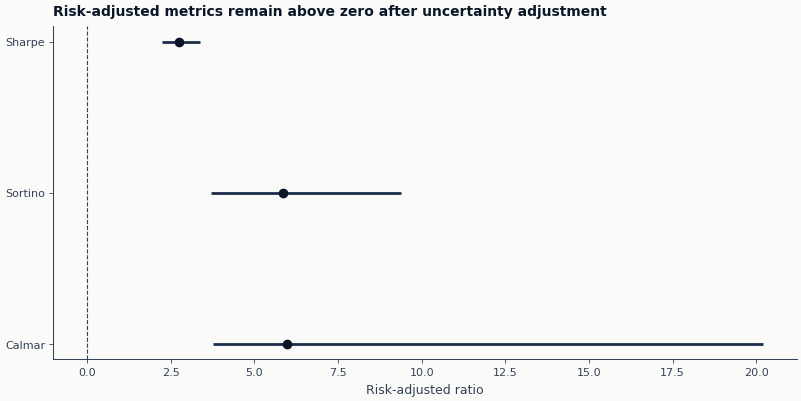

In [26]:
ew_val = load_benchmark_metrics(CASE_STUDY, RANK1_LABEL, period="validation")
forest_metrics = [
    ("Sharpe", full["sharpe"], full["sharpe_ci95_lo"], full["sharpe_ci95_hi"]),
    ("Sortino", full["sortino"], full["sortino_ci95_lo"], full["sortino_ci95_hi"]),
    ("Calmar", full["calmar"], full["calmar_ci95_lo"], full["calmar_ci95_hi"]),
]

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(forest_metrics))
points = np.array([m[1] for m in forest_metrics])
los = np.array([m[2] for m in forest_metrics])
his = np.array([m[3] for m in forest_metrics])
ax.errorbar(
    points,
    y,
    xerr=[points - los, his - points],
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    elinewidth=2.0,
    capsize=4,
    markersize=7,
)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels([m[0] for m in forest_metrics])
ax.invert_yaxis()
ax.set_xlabel("Risk-adjusted ratio")
add_message_title(ax, "Risk-adjusted metrics remain above zero after uncertainty adjustment")
fig.show()

In [27]:
strat_returns_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "daily_returns.parquet"
strat_df = (
    pl.read_parquet(strat_returns_path)
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("daily_return").alias("strategy"))
)

bench_val = (
    load_benchmark_returns(CASE_STUDY, RANK1_LABEL, period="validation")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("ew_return").alias("benchmark"))
)

aligned = strat_df.join(bench_val, on="ts", how="inner").sort("ts")
print(
    f"Validation overlay window: {aligned['ts'].min()} → {aligned['ts'].max()}, n={aligned.height}"
)

Validation overlay window: 2006-11-30 → 2015-12-31, n=110


The validation Sharpe CI is reported above with its `ci_status`
classification. PSR p-value tests H0: Sharpe ≤ 0; the DSR variants
above (raw / MP / ER) report the selection-adjusted equivalent across
the k_variants in the family cohort, with ER the
maintainer-recommended default. PBO is the probability of backtest
overfitting from CSCV on the per-fold Sharpe matrix; §6's val→ho
closure provides the orthogonal out-of-sample check.

The cumulative-return plot shows the validation trajectory against
the EW universe. The y-axis encodes the cumulative product of monthly
returns from the dollar-neutral long-short structure, and over 110
months compounding produces large theoretical end-points. The
headline annualized-return CI reflects that compounding scale, not a
directly tradeable rate; §5 puts the gross profile against realistic
implementation friction.

### Second benchmark: Fama-French market

The EW universe is the inside-the-strategy benchmark (untimed
allocation across the same names). The Fama-French market series
(Mkt-RF + RF) is the classical academic external benchmark - what
every cross-sectional anomaly is implicitly compared against. It
matches the strategy's monthly cadence directly. Beta against the
market quantifies whether the long-short construction achieves the
market-neutrality it nominally targets.

In [28]:
ff_m = load_ff_market_returns(
    start=aligned["ts"].min(),
    end=aligned["ts"].max(),
    frequency="monthly",
)
ff_aligned = align_external_benchmark_monthly(
    aligned.select("ts", "strategy"),
    ff_m,
    timestamp_col="ts",
)
ff_diag = compute_benchmark_diagnostics(
    ff_aligned["strategy"].to_numpy(),
    ff_aligned["benchmark_return"].to_numpy(),
    PERIODS_PER_YEAR,
)
ew_diag = compute_benchmark_diagnostics(
    aligned["strategy"].to_numpy(),
    aligned["benchmark"].to_numpy(),
    PERIODS_PER_YEAR,
)

In [29]:
benchmark_table = pl.DataFrame(
    [
        {
            "benchmark": "EW universe (validation)",
            "n_periods": ew_diag["n"],
            "info_ratio": _fmt(ew_diag["info_ratio"], ".3f"),
            "beta": _fmt(ew_diag["beta"], ".3f"),
            "correlation": _fmt(ew_diag["correlation"], ".3f"),
            "tracking_error": _fmt(ew_diag["tracking_error"], ".3f"),
        },
        {
            "benchmark": "FF-market (Mkt-RF + RF, monthly)",
            "n_periods": ff_diag["n"],
            "info_ratio": _fmt(ff_diag["info_ratio"], ".3f"),
            "beta": _fmt(ff_diag["beta"], ".3f"),
            "correlation": _fmt(ff_diag["correlation"], ".3f"),
            "tracking_error": _fmt(ff_diag["tracking_error"], ".3f"),
        },
    ]
)
print("Strategy diagnostics vs benchmarks:")
print(benchmark_table)

Strategy diagnostics vs benchmarks:
shape: (2, 6)
┌─────────────────────────────────┬───────────┬────────────┬────────┬─────────────┬────────────────┐
│ benchmark                       ┆ n_periods ┆ info_ratio ┆ beta   ┆ correlation ┆ tracking_error │
│ ---                             ┆ ---       ┆ ---        ┆ ---    ┆ ---         ┆ ---            │
│ str                             ┆ i64       ┆ str        ┆ str    ┆ str         ┆ str            │
╞═════════════════════════════════╪═══════════╪════════════╪════════╪═════════════╪════════════════╡
│ EW universe (validation)        ┆ 110       ┆ 1.602      ┆ 0.096  ┆ 0.112       ┆ 0.263          │
│ FF-market (Mkt-RF + RF, monthl… ┆ 109       ┆ 1.695      ┆ -0.019 ┆ -0.017      ┆ 0.244          │
└─────────────────────────────────┴───────────┴────────────┴────────┴─────────────┴────────────────┘


### Sub-period decomposition (5-year buckets)

Pooled validation Sharpe averages over ~9 years of monthly
observations; the realized number can be anchored by a small number
of years rather than evenly distributed. The buckets below decompose
val into two ~5y windows plus the 12-month holdout. We resolve the
holdout through the unique complete-strategy-spec match within the
frozen training lineage - the same rule §6 uses for the paired closure.

In [30]:
ho_panel = (
    pl.read_parquet(CASE_DIR / "run_log" / "backtest" / HO_HASH / "daily_returns.parquet")
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select("ts", pl.col("daily_return").alias("strategy"))
)
bench_ho = (
    load_benchmark_returns(CASE_STUDY, RANK1_LABEL, period="holdout")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select("ts", pl.col("ew_return").alias("benchmark"))
)
ho_aligned = (
    ho_panel.join(bench_ho, on="ts", how="inner").sort("ts")
    if ho_panel.height > 0
    else pl.DataFrame()
)

val_buckets = [
    ("2006-2010 (val)", _dt.date(2006, 1, 1), _dt.date(2010, 12, 31)),
    ("2011-2015 (val)", _dt.date(2011, 1, 1), _dt.date(2015, 12, 31)),
]
val_table = compute_subperiod_diagnostics(
    aligned,
    val_buckets,
    periods_per_year=PERIODS_PER_YEAR,
)
ho_table = (
    compute_subperiod_diagnostics(
        ho_aligned,
        [("2016 (ho)", _dt.date(2016, 1, 1), _dt.date(2016, 12, 31))],
        periods_per_year=PERIODS_PER_YEAR,
    )
    if ho_aligned.height > 0
    else pl.DataFrame()
)
subperiod_table = pl.concat([val_table, ho_table]) if ho_table.height > 0 else val_table
print("Sub-period decomposition (validation 5y buckets + holdout):")
print(subperiod_table)

Sub-period decomposition (validation 5y buckets + holdout):
shape: (3, 8)
┌──────────────┬─────┬────────────┬────────────┬──────────┬─────────────┬────────────┬─────────────┐
│ bucket       ┆ n   ┆ cum_return ┆ ann_return ┆ sharpe   ┆ max_drawdow ┆ beta_vs_bm ┆ info_ratio_ │
│ ---          ┆ --- ┆ ---        ┆ ---        ┆ ---      ┆ n           ┆ ---        ┆ vs_bm       │
│ str          ┆ i64 ┆ f64        ┆ f64        ┆ f64      ┆ ---         ┆ f64        ┆ ---         │
│              ┆     ┆            ┆            ┆          ┆ f64         ┆            ┆ f64         │
╞══════════════╪═════╪════════════╪════════════╪══════════╪═════════════╪════════════╪═════════════╡
│ 2006-2010    ┆ 50  ┆ 7.688663   ┆ 0.680153   ┆ 2.550674 ┆ -0.10135    ┆ 0.143975   ┆ 1.488419    │
│ (val)        ┆     ┆            ┆            ┆          ┆             ┆            ┆             │
│ 2011-2015    ┆ 60  ┆ 7.741752   ┆ 0.542836   ┆ 3.06622  ┆ -0.042067   ┆ -0.030657  ┆ 1.785996    │
│ (val)        ┆ 

## §4 Risk and drawdown analysis

Risk metrics use the validation-window strategy returns paired against
the validation EW benchmark. The headline CIs and tail-risk read
cover the substantive risk profile; per-fold decomposition (where
available in `backtest_fold_metrics`) localizes the realized Sharpe
across the CV folds.

In [31]:
strat_arr = aligned["strategy"].to_numpy()
bench_arr = aligned["benchmark"].to_numpy()
ts_arr = aligned["ts"].to_list()

pa = PortfolioAnalysis(
    returns=strat_arr,
    benchmark=bench_arr,
    dates=ts_arr,
    periods_per_year=PERIODS_PER_YEAR,
)

dd = pa.compute_drawdown_analysis()
print("Drawdown analysis (validation window):")
print(dd)

Drawdown analysis (validation window):
DrawdownResult(current_drawdown=0.0, max_drawdown=-0.10134952076664643, avg_drawdown=-0.029658728142072516, underwater_curve=shape: (110,)
Series: 'drawdown' [f64]
[
	0.0
	0.0
	-0.021227
	0.0
	0.0
	…
	0.0
	0.0
	0.0
	0.0
	0.0
], top_drawdowns=[DrawdownPeriod(peak_date=datetime.date(2007, 7, 31), valley_date=datetime.date(2007, 9, 28), recovery_date=datetime.date(2007, 12, 31), depth=np.float64(-0.10134952076664643), duration_days=2, recovery_days=3), DrawdownPeriod(peak_date=datetime.date(2015, 3, 31), valley_date=datetime.date(2015, 4, 30), recovery_date=datetime.date(2015, 5, 29), depth=np.float64(-0.04206737999999995), duration_days=1, recovery_days=1), DrawdownPeriod(peak_date=datetime.date(2010, 9, 30), valley_date=datetime.date(2010, 10, 29), recovery_date=datetime.date(2010, 12, 31), depth=np.float64(-0.036837259999999886), duration_days=1, recovery_days=2), DrawdownPeriod(peak_date=datetime.date(2013, 4, 30), valley_date=datetime.date(2013,

In [32]:
roll = pa.compute_rolling_metrics(windows=[12], metrics=["sharpe", "beta"])
print("Rolling-window keys:")
print({k: type(v).__name__ for k, v in roll.items()} if isinstance(roll, dict) else roll)

tail_table = pl.DataFrame(
    [
        {"metric": "Volatility (ann.)", "value": f"{full['volatility']:.4f}"},
        {"metric": "VaR 95% (period)", "value": f"{full['var_95']:.4f}"},
        {"metric": "CVaR 95% (period)", "value": f"{full['cvar_95']:.4f}"},
        {"metric": "Tail ratio", "value": f"{full['tail_ratio']:.3f}"},
        {"metric": "Skewness", "value": f"{full['skewness']:.3f}"},
        {"metric": "Kurtosis", "value": f"{full['kurtosis']:.3f}"},
    ]
)
print()
print("Tail risk profile:")
print(tail_table)

Rolling-window keys:
RollingMetricsResult(windows=[12], dates=shape: (110,)
Series: 'date' [date]
[
	2006-11-30
	2006-12-29
	2007-01-31
	2007-02-28
	2007-03-30
	…
	2015-08-31
	2015-09-30
	2015-10-30
	2015-11-30
	2015-12-31
], sharpe={12: shape: (110,)
Series: 'sharpe_12d' [f64]
[
	null
	null
	null
	null
	null
	…
	4.096185
	4.059992
	3.913186
	4.025957
	4.415675
]}, volatility={}, returns={}, beta={12: shape: (110,)
Series: 'beta_12d' [f64]
[
	null
	null
	null
	null
	null
	…
	-0.809762
	-0.650102
	-0.550549
	-0.544951
	-0.626015
]})

Tail risk profile:
shape: (6, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Volatility (ann.) ┆ 0.1815  │
│ VaR 95% (period)  ┆ -0.0281 │
│ CVaR 95% (period) ┆ -0.0403 │
│ Tail ratio        ┆ 4.620   │
│ Skewness          ┆ 1.355   │
│ Kurtosis          ┆ 4.477   │
└───────────────────┴─────────┘


In [33]:
fold_df = load_backtest_fold_metrics(CASE_STUDY, backtest_hash=TOP_HASH)
print(f"Per-fold breakdown: {fold_df.height} rows.")
if fold_df.is_empty():
    print(
        "  (Empty - fold writer did not register fold metrics for this rank-1 "
        "lineage. Headline CI in §3 stands in for fold variance.)"
    )
else:
    print(fold_df.select("fold_id", "sharpe", "max_drawdown", "n_days"))

Per-fold breakdown: 10 rows.
shape: (10, 4)
┌─────────┬──────────┬──────────────┬────────┐
│ fold_id ┆ sharpe   ┆ max_drawdown ┆ n_days │
│ ---     ┆ ---      ┆ ---          ┆ ---    │
│ i64     ┆ f64      ┆ f64          ┆ f64    │
╞═════════╪══════════╪══════════════╪════════╡
│ 0       ┆ 4.244408 ┆ -0.042067    ┆ 11.0   │
│ 1       ┆ 3.274082 ┆ -0.010307    ┆ 11.0   │
│ 2       ┆ 1.534014 ┆ -0.02971     ┆ 11.0   │
│ 3       ┆ 3.376122 ┆ -0.022522    ┆ 11.0   │
│ 4       ┆ 2.36382  ┆ -0.005143    ┆ 11.0   │
│ 5       ┆ 4.293019 ┆ -0.036837    ┆ 11.0   │
│ 6       ┆ 2.687914 ┆ -0.025539    ┆ 11.0   │
│ 7       ┆ 4.420394 ┆ 0.0          ┆ 11.0   │
│ 8       ┆ 3.735443 ┆ -0.016825    ┆ 11.0   │
│ 9       ┆ 0.869504 ┆ -0.10135     ┆ 11.0   │
└─────────┴──────────┴──────────────┴────────┘


The validation-window max-drawdown CI quantifies the depth of the
worst peak-to-trough excursion over the 110 observed months; the lower
bound is a meaningful tail-risk read: if a worst case at the lower
bound were realized in deployment, depth would be materially deeper
than the point estimate. Annualized volatility reflects the
dollar-neutral leverage assumption; tail kurtosis and the tail ratio
characterize the symmetry of the realized return distribution.

## §4b Inline diagnostic panels

§8 generates the standalone tear sheet HTML when feasible (the
Plotly Dash design renders best as a multi-tab app). For inline
review we lift the diagnostic library's core panels off the
validation `PortfolioAnalysis`. Trade-conditional panels - IC time
series, decile returns, prediction–trade alignment - are
**unavailable** for this case study: the vectorized backtester used
here emits `daily_returns.parquet` and `weights.parquet` but no
`trades.parquet`, and the bridge layer that builds a `BacktestProfile`
requires per-trade fills to construct the ML surfaces. Per the strategy-analysis
convention we do not synthesize fills. The IC analysis covered in
§3 (forest plot) and §6 (paired holdout) is the substitute; the
return-distribution and risk views below complete the inline picture.

**Cumulative return.** Validation-window equity vs. EW universe.

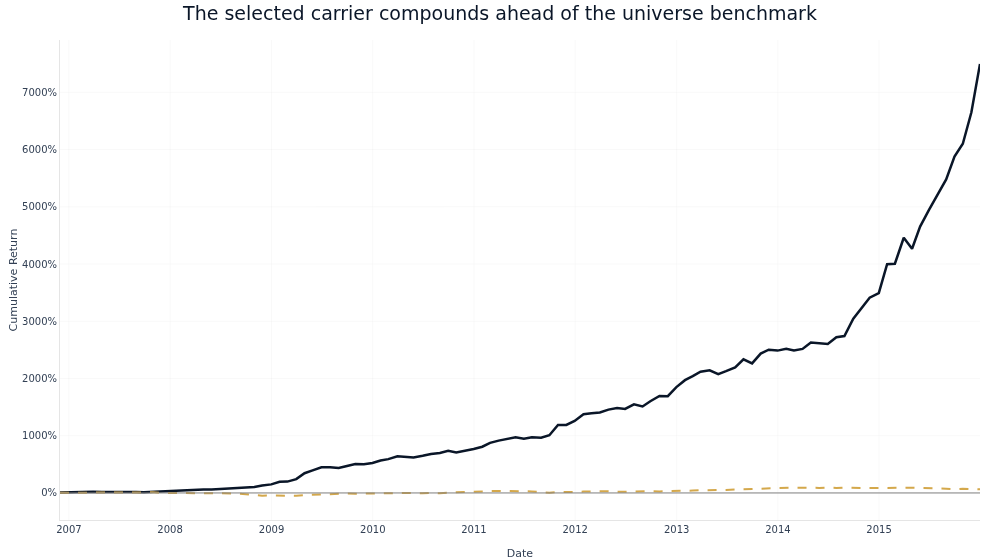

In [34]:
fig_cum = plot_cumulative_returns(pa, benchmark_label="EW universe")
fig_cum.update_layout(title="The selected carrier compounds ahead of the universe benchmark")
fig_cum.show()

**Annual returns.** Calendar-year strategy vs. benchmark bars.

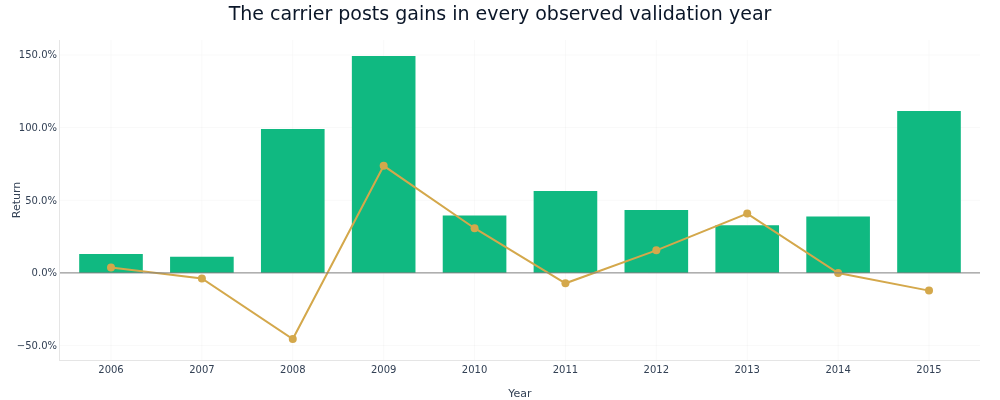

In [35]:
fig_annual = plot_annual_returns_bar(pa, benchmark_label="EW universe")
fig_annual.update_layout(title="The carrier posts gains in every observed validation year")
fig_annual.show()

**Monthly returns heatmap.** Year×month return surface.

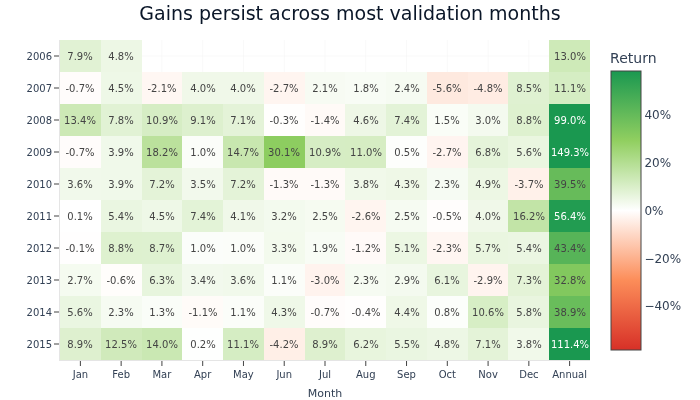

In [36]:
fig_monthly = plot_monthly_returns_heatmap(pa)
fig_monthly.update_layout(title="Gains persist across most validation months")
fig_monthly.show()

**Returns distribution.** Monthly return histogram against a normal
overlay; complements §4's tail-ratio table.

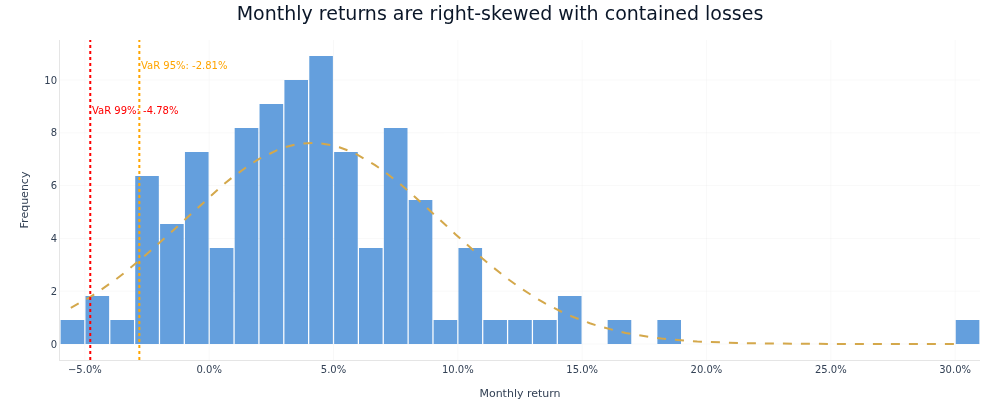

In [37]:
fig_dist = plot_returns_distribution(pa)
fig_dist.update_layout(title="Monthly returns are right-skewed with contained losses")
fig_dist.update_xaxes(title_text="Monthly return")
for annotation, y_position in zip(fig_dist.layout.annotations, [0.92, 0.78], strict=False):
    annotation.update(y=y_position, yshift=0)
fig_dist.show()

**Drawdown underwater.** Underwater curve over the strategy series;
reads against §4's max-drawdown number.

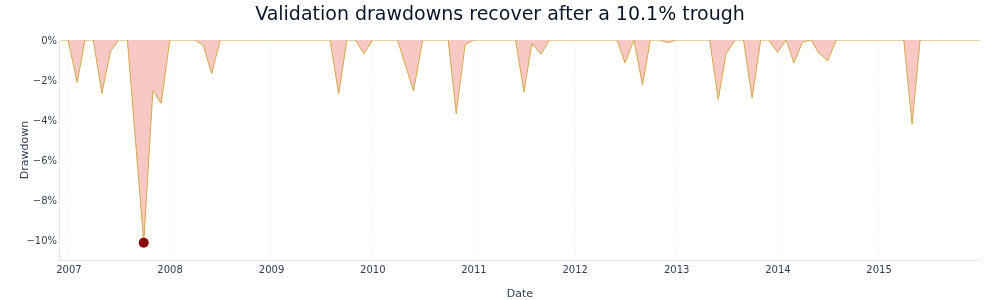

In [38]:
fig_underwater = plot_drawdown_underwater(pa)
fig_underwater.update_layout(
    title=f"Validation drawdowns recover after a {abs(full['max_drawdown']):.1%} trough"
)
fig_underwater.show()

**Rolling Sharpe.** Twelve- and 36-month rolling Sharpe locate when the
realized Sharpe is paid out.

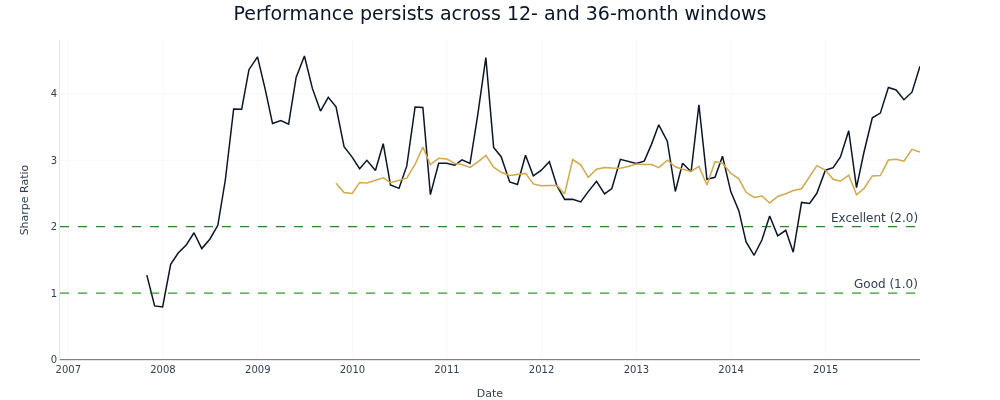

In [39]:
fig_rolling = plot_rolling_sharpe(pa, windows=[12, 36])
for trace, label in zip(fig_rolling.data, ["12 months", "36 months"], strict=False):
    trace.name = label
fig_rolling.update_layout(title="Performance persists across 12- and 36-month windows")
fig_rolling.show()

**Tail risk panel.** VaR/CVaR at 95/99% with the empirical tail.

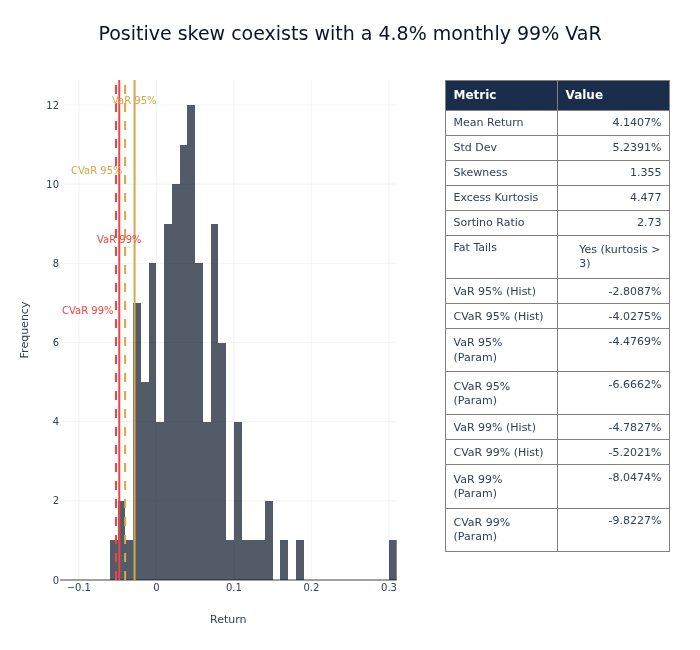

In [40]:
fig_tail = plot_tail_risk_analysis(strat_arr)
_var_99 = float(np.quantile(strat_arr, 0.01))
for annotation, y_position in zip(
    fig_tail.layout.annotations,
    [0.96, 0.82, 0.68, 0.54],
    strict=False,
):
    annotation.update(y=y_position, yanchor="middle")
fig_tail.update_layout(
    title=f"Positive skew coexists with a {abs(_var_99):.1%} monthly 99% VaR",
    height=650,
    margin={"b": 70, "l": 60, "r": 30, "t": 80},
)
fig_tail.show()

## §5 Friction budget & cost sensitivity

Long-short equity at monthly cadence has limited turnover but doubled
cost exposure (long + short legs) and short-leg borrow costs. Two
layers cover the friction budget:

1. **Registry cost sweep** - the cost_sensitivity stage walked an
   11-level cost grid (0–50 bps per leg) on a base allocation lineage;
   the curve below shows how Sharpe responds to friction at the
   asset-class-realistic spread regime.
2. **Micro-cap-realistic extended grid** - because both long and short
   legs concentrate in small-cap, illiquid names, asset-class-mean
   spreads understate execution costs; the extended grid (up to 500
   bps one-way) and turnover overlay surface the deployment-relevant
   cost regime for the names actually selected.

In [41]:
with sqlite3.connect(str(_db)) as _con:
    cost_df = pl.DataFrame(
        _con.execute(
            """
            SELECT
                b.spec_json,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi,
                bm.max_drawdown
            FROM backtest_runs b
            JOIN backtest_metrics bm ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p   ON b.prediction_hash = p.prediction_hash
            WHERE b.stage = 'cost_sensitivity'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=[
            "spec_json",
            "sharpe",
            "sharpe_ci95_lo",
            "sharpe_ci95_hi",
            "max_drawdown",
        ],
        orient="row",
    )

In [42]:
def _cost_bps(spec_str: str) -> float:
    spec = json.loads(spec_str)
    bc = spec.get("backtest_config", {})
    comm = bc.get("commission", {}) or {}
    slip = bc.get("slippage", {}) or {}
    return float((comm.get("rate", 0) + slip.get("rate", 0)) * 10000)


cost_df = cost_df.with_columns(
    pl.col("spec_json").map_elements(_cost_bps, return_dtype=pl.Float64).alias("cost_bps")
)
cost_curve = (
    cost_df.group_by("cost_bps")
    .agg(
        sharpe_max=pl.col("sharpe").max(),
        sharpe_min=pl.col("sharpe").min(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_ci_lo=pl.col("sharpe_ci95_lo").min(),
        sharpe_ci_hi=pl.col("sharpe_ci95_hi").max(),
        n=pl.len(),
    )
    .sort("cost_bps")
)
print("Cost sensitivity curve (validation, all configs):")
print(cost_curve)

Cost sensitivity curve (validation, all configs):
shape: (11, 7)
┌──────────┬────────────┬────────────┬───────────────┬──────────────┬──────────────┬─────┐
│ cost_bps ┆ sharpe_max ┆ sharpe_min ┆ sharpe_median ┆ sharpe_ci_lo ┆ sharpe_ci_hi ┆ n   │
│ ---      ┆ ---        ┆ ---        ┆ ---           ┆ ---          ┆ ---          ┆ --- │
│ f64      ┆ f64        ┆ f64        ┆ f64           ┆ f64          ┆ f64          ┆ u32 │
╞══════════╪════════════╪════════════╪═══════════════╪══════════════╪══════════════╪═════╡
│ 0.0      ┆ 2.926074   ┆ 2.926074   ┆ 2.926074      ┆ 2.50795      ┆ 3.59055      ┆ 1   │
│ 1.0      ┆ 2.912318   ┆ 2.912318   ┆ 2.912318      ┆ 2.494594     ┆ 3.578219     ┆ 1   │
│ 2.0      ┆ 2.898563   ┆ 2.898563   ┆ 2.898563      ┆ 2.481237     ┆ 3.563218     ┆ 1   │
│ 3.0      ┆ 2.884809   ┆ 2.884809   ┆ 2.884809      ┆ 2.467621     ┆ 3.544241     ┆ 1   │
│ 5.0      ┆ 2.857304   ┆ 2.857304   ┆ 2.857304      ┆ 2.438033     ┆ 3.506095     ┆ 1   │
│ …        ┆ …          ┆

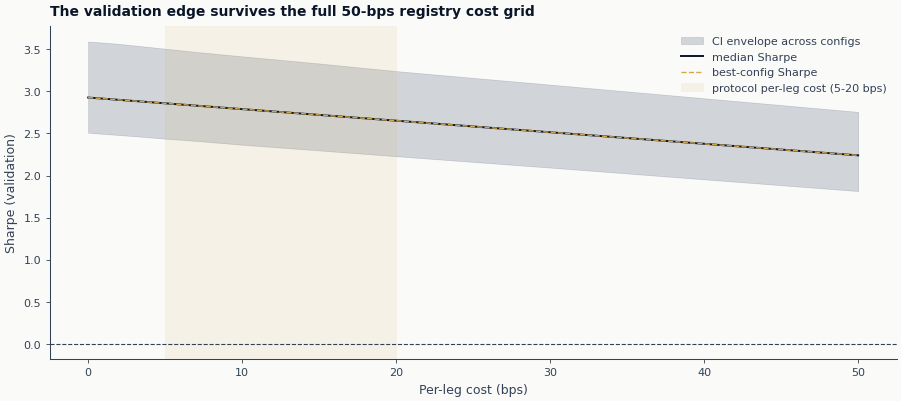

In [43]:
cost_range = setup["costs"]["per_leg_cost_bps_range"]
fig, ax = plt.subplots(figsize=(9, 4))
xs = cost_curve["cost_bps"].to_numpy()
ax.fill_between(
    xs,
    cost_curve["sharpe_ci_lo"].to_numpy(),
    cost_curve["sharpe_ci_hi"].to_numpy(),
    alpha=0.18,
    color=COLORS["slate"],
    label="CI envelope across configs",
)
ax.plot(
    xs,
    cost_curve["sharpe_median"].to_numpy(),
    color=COLORS["blue"],
    linewidth=1.4,
    label="median Sharpe",
)
ax.plot(
    xs,
    cost_curve["sharpe_max"].to_numpy(),
    color=COLORS["amber"],
    linewidth=1.0,
    linestyle="--",
    label="best-config Sharpe",
)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8, linestyle="--")
ax.axvspan(
    cost_range[0],
    cost_range[1],
    color=COLORS["amber"],
    alpha=0.10,
    label=f"protocol per-leg cost ({cost_range[0]}-{cost_range[1]} bps)",
)
ax.set_xlabel("Per-leg cost (bps)")
ax.set_ylabel("Sharpe (validation)")
add_message_title(ax, "The validation edge survives the full 50-bps registry cost grid")
ax.legend(loc="best", fontsize=8, frameon=False)
fig.show()

In [44]:
crossing_rows = cost_curve.filter(pl.col("sharpe_ci_lo") > 0)
if not crossing_rows.is_empty():
    breakeven = crossing_rows["cost_bps"].max()
    print(f"Best-config Sharpe CI lower bound stays > 0 up to: {breakeven:.0f} bps")
else:
    print("Best-config Sharpe CI lower bound never exceeds 0 across the cost grid.")

print(
    f"Protocol per-leg cost: {cost_range} bps. "
    f"Borrow note: {setup['costs'].get('borrow_cost_note', '-')}. "
    f"Era note: {setup['costs'].get('era_note', '-')}."
)
print("See Chapter 18 for transaction-cost framework details.")

Best-config Sharpe CI lower bound stays > 0 up to: 50 bps
Protocol per-leg cost: [5, 20] bps. Borrow note: Long-short requires borrow for the short leg.. Era note: Pre-2001 spreads 15-30 bps; post-2001 (decimalization) 5-15 bps..
See Chapter 18 for transaction-cost framework details.


Across the protocol per-leg cost range (5-20 bps), the best-config
Sharpe stays strongly positive with the CI lower bound well above
zero. The slope is gentle: monthly cadence and a top-K = 50
concentration limit turnover, so cost erosion is a function of
round-trip cost × turnover rather than spread alone. This curve
answers the question "is this strategy robust to broker fees within
the asset-class-realistic spread regime?" The answer is yes across
the registry's tested range. The next sub-section
turns to the harder question: how much do the prices the strategy
actually trades at differ from the universe-mean spread?

### Illiquidity profile of selected stocks

The actual allocation weights identify the 50 long and 50 short
positions held each month. Joining those weights to the prepared
feature panel reveals the implemented portfolio's liquidity profile
without sorting on future realized returns.

In [45]:
_attr_returns_path = strat_returns_path
_strategy_rets = pd.Series(
    pl.read_parquet(_attr_returns_path).sort("timestamp")["daily_return"].to_numpy(),
    index=pd.to_datetime(
        pl.read_parquet(_attr_returns_path).sort("timestamp")["timestamp"].to_list()
    ),
    name="strategy",
)
_start = str(_strategy_rets.index.min().date())
_end = str(_strategy_rets.index.max().date())

_liq_features = ["LME", "Spread", "LTurnover", "IdioVol"]
_weights_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "weights.parquet"
_weights = pl.read_parquet(_weights_path).select(
    pl.col("timestamp").cast(pl.Date),
    pl.col("symbol").cast(pl.String),
    "weight",
)
_features = (
    pl.scan_parquet(CASE_DIR / "features" / "financial.parquet")
    .select(
        pl.col("timestamp").cast(pl.Date),
        pl.col("symbol").cast(pl.String),
        *_liq_features,
    )
    .filter(pl.col("timestamp").is_in(_weights["timestamp"].unique().implode()))
    .collect()
)
_selected = _weights.join(_features, on=["timestamp", "symbol"], how="inner", validate="m:1")
if _selected.height != _weights.height:
    raise RuntimeError("Every realized portfolio weight must match one prepared feature row.")

In [46]:
_selected_long = _selected.with_columns(
    pl.when(pl.col("weight") > 0).then(pl.lit("Long")).otherwise(pl.lit("Short")).alias("segment")
).unpivot(index="segment", on=_liq_features, variable_name="feature", value_name="value")
_universe_long = _features.unpivot(
    on=_liq_features, variable_name="feature", value_name="value"
).with_columns(pl.lit("Universe").alias("segment"))
_liq_df = (
    pl.concat([_selected_long, _universe_long], how="diagonal")
    .group_by("segment", "feature")
    .agg(pl.col("value").mean().alias("mean"))
    .sort("feature", "segment")
)
print("Actual-weight liquidity profile (rank-normalized features):")
_liq_df

Actual-weight liquidity profile (rank-normalized features):


segment,feature,mean
str,str,f64
"""Long""","""IdioVol""",0.318571
"""Short""","""IdioVol""",0.385498
"""Universe""","""IdioVol""",1.5860e-18
"""Long""","""LME""",-0.341187
"""Short""","""LME""",-0.293346
…,…,…
"""Short""","""LTurnover""",0.031042
"""Universe""","""LTurnover""",6.1677e-20
"""Long""","""Spread""",0.362705


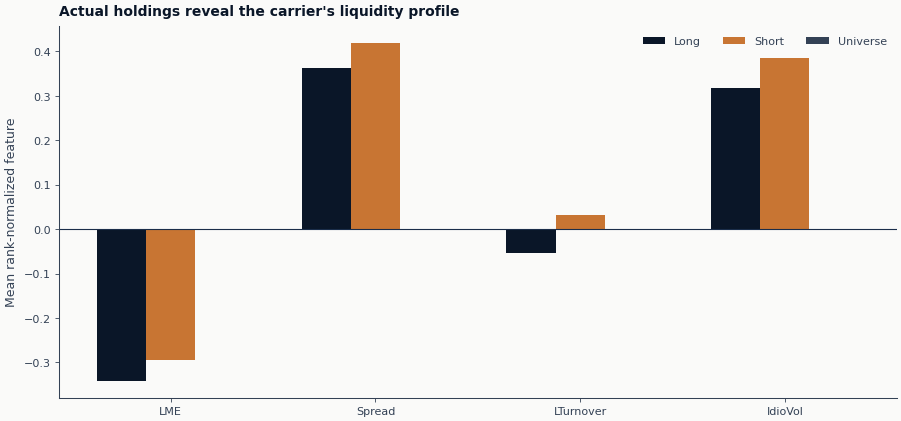

In [47]:
_liq_wide = _liq_df.pivot(on="segment", index="feature", values="mean")
_x = np.arange(len(_liq_features))
fig_liq, ax_liq = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
for _offset, (_segment, _color) in enumerate(
    [("Long", COLORS["blue"]), ("Short", COLORS["copper"]), ("Universe", COLORS["neutral"])]
):
    _values = [
        _liq_wide.filter(pl.col("feature") == feature)[_segment][0] for feature in _liq_features
    ]
    ax_liq.bar(_x + (_offset - 1) * 0.24, _values, 0.24, label=_segment, color=_color)
ax_liq.axhline(0, color=COLORS["slate"], linewidth=0.8)
ax_liq.set_xticks(_x, _liq_features)
ax_liq.set_ylabel("Mean rank-normalized feature")
add_message_title(ax_liq, "Actual holdings reveal the carrier's liquidity profile")
ax_liq.legend(frameon=False, ncol=3)
fig_liq.show()

Negative LME denotes smaller firms; positive Spread, LTurnover, and
IdioVol denote more difficult execution. The chart measures those
properties on realized holdings. It does not infer positions from
future returns or translate normalized features into basis points.

### Extended cost grid (micro-cap-realistic)

Because the registry's cost_sensitivity stage caps at 50 bps per leg,
we extend the grid to capture micro-cap-realistic spreads, scaling
the rank-1's gross monthly returns by an explicit turnover × cost
product. This captures the Avramov, Cheng, and Metzker (2020)
critique materialized: ML profitability that looks strong at
universe-mean spreads can erode once economic restrictions of the
names actually selected are applied.

In [48]:
_turnover_pcts = [0.10, 0.25, 0.50, 0.75, 1.00]
_cost_bps_extended = [0, 10, 50, 100, 200, 300, 500]
_grid_ext = []

for turnover in _turnover_pcts:
    for cost_bps in _cost_bps_extended:
        cost_per_period = turnover * 2 * (cost_bps / 10_000)
        adj_rets = _strategy_rets - cost_per_period
        sharpe_adj = (
            float(adj_rets.mean() / adj_rets.std() * np.sqrt(PERIODS_PER_YEAR))
            if adj_rets.std() > 0
            else 0.0
        )
        _grid_ext.append(
            {
                "turnover_pct": turnover,
                "cost_bps": cost_bps,
                "sharpe": sharpe_adj,
                "annual_drag": cost_per_period * PERIODS_PER_YEAR,
            }
        )

_ext_df = pd.DataFrame(_grid_ext)
_ext_heat = _ext_df.pivot(index="turnover_pct", columns="cost_bps", values="sharpe")

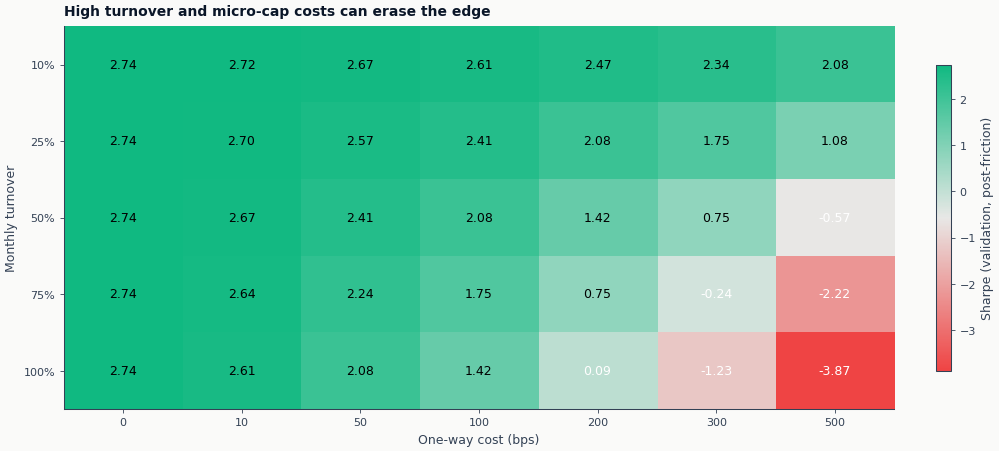

In [49]:
_cost_cmap = LinearSegmentedColormap.from_list("ml4t_cost", ml4t_diverging())

fig_ext, ax_ext = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
im = ax_ext.imshow(
    _ext_heat.values,
    cmap=_cost_cmap,
    aspect="auto",
    vmin=min(0, _ext_heat.values.min()),
    vmax=_ext_heat.values.max(),
)
ax_ext.set_xticks(range(len(_cost_bps_extended)))
ax_ext.set_xticklabels([f"{c}" for c in _cost_bps_extended])
ax_ext.set_yticks(range(len(_turnover_pcts)))
ax_ext.set_yticklabels([f"{t:.0%}" for t in _turnover_pcts])
ax_ext.set_xlabel("One-way cost (bps)")
ax_ext.set_ylabel("Monthly turnover")
add_message_title(ax_ext, "High turnover and micro-cap costs can erase the edge")
for i in range(len(_turnover_pcts)):
    for j in range(len(_cost_bps_extended)):
        val = _ext_heat.values[i, j]
        color = "white" if val < 0.5 else "black"
        ax_ext.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)
fig_ext.colorbar(im, ax=ax_ext, label="Sharpe (validation, post-friction)", shrink=0.8)
fig_ext.show()

In [50]:
print("Extended turnover × cost sensitivity (Sharpe ratios):")
pl.from_pandas(_ext_heat.reset_index())

Extended turnover × cost sensitivity (Sharpe ratios):


turnover_pct,0,10,50,100,200,300,500
f64,f64,f64,f64,f64,f64,f64,f64
0.1,2.737795,2.724571,2.671675,2.605555,2.473315,2.341075,2.076596
0.25,2.737795,2.704735,2.572495,2.407195,2.076596,1.745997,1.084798
0.5,2.737795,2.671675,2.407195,2.076596,1.415397,0.754199,-0.568198
0.75,2.737795,2.638615,2.241896,1.745997,0.754199,-0.237599,-2.221195
1.0,2.737795,2.605555,2.076596,1.415397,0.093,-1.229397,-3.874191


In [51]:
for turnover in _turnover_pcts:
    row = _ext_df[_ext_df["turnover_pct"] == turnover].sort_values("cost_bps")
    positive = row[row["sharpe"] > 0]
    if positive.empty:
        print(f"  Turnover {turnover:.0%}: negative at all cost levels")
    elif len(positive) < len(row):
        max_cost = int(positive.iloc[-1]["cost_bps"])
        print(f"  Turnover {turnover:.0%}: positive up to {max_cost} bps one-way")
    else:
        print(
            f"  Turnover {turnover:.0%}: positive at all levels "
            f"(max tested: {_cost_bps_extended[-1]} bps)"
        )

  Turnover 10%: positive at all levels (max tested: 500 bps)
  Turnover 25%: positive at all levels (max tested: 500 bps)
  Turnover 50%: positive up to 300 bps one-way
  Turnover 75%: positive up to 200 bps one-way
  Turnover 100%: positive up to 200 bps one-way


The extended grid quantifies the binding constraint: the universe is
tradeable but the names actually selected can be expensive. At 50%
monthly turnover and 200 bps one-way cost, Sharpe falls to about 1.42;
at 500 bps it turns negative. These are scenarios, not cost estimates.
**Implementation framing**: this is not a kill condition under the §1
universal gates because the validation Sharpe CI lower bound is ≥ 0, but it is
the dominant capacity caveat. A practical deployment would either
restrict the universe to stocks above a liquidity threshold (which
would shrink the long-short spread) or accept the gross alpha as a
theoretical upper bound for what this feature set extracts. Chapter 18
develops the transaction-cost framework that translates this grid into
a deployment decision.

## §6 Holdout closure with paired bootstrap

The holdout window is calendar 2016: 12 monthly observations. With
only 12 periods, paired-bootstrap CIs are wide; the classification
this section produces is therefore as much about CI width as about
point-estimate magnitude. Two paired tests anchor the closure: (i) the
holdout backtest that uniquely matches the validation rank-1's complete
strategy spec within its training lineage versus the validation rank-1
itself ("did Sharpe carry?"), and (ii) the
holdout backtest versus the holdout-window equal-weight benchmark
("did the strategy beat random in the holdout?").

Numbers come from `backtest_paired_metrics`, never from
val_sharpe minus holdout_sharpe arithmetic. The holdout mate is
the strict registered mate of the validation rank-1 carrier.

In [52]:
print(f"Validation rank-1 hash:  {TOP_HASH}")
print(f"Holdout mate hash:       {HO_HASH}")
print(f"Carrier: {RANK1_FAMILY}/{RANK1_CONFIG}/{RANK1_LABEL}, equal-weight allocation")

ho_full = load_backtest_metrics(CASE_STUDY, backtest_hash=HO_HASH).row(0, named=True)
val_full = full

Validation rank-1 hash:  b43559d60839
Holdout mate hash:       3d39bbd68481
Carrier: gbm/default_huber/fwd_ret_1m_win, equal-weight allocation


In [53]:
val_ho_pair = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="val_rank1_self",
)
if val_ho_pair.is_empty():
    raise RuntimeError("Missing required val_rank1_self paired metric.")
if val_ho_pair.height != 1 or val_ho_pair["benchmark_hash"].item() != TOP_HASH:
    raise RuntimeError("Validation-to-holdout pair does not identify the frozen carrier exactly.")
vh = val_ho_pair.row(0, named=True)

In [54]:
def _diff_row(
    label: str,
    v: float,
    h: float,
    diff: float | None,
    lo: float | None,
    hi: float | None,
    p: float | None,
) -> dict:
    return {
        "metric": label,
        "validation": _fmt(v, ".4f"),
        "holdout": _fmt(h, ".4f"),
        "diff (h-v)": _fmt(diff, ".4f") if diff is not None else "-",
        "diff CI95": f"[{_fmt(lo, '.4f')}, {_fmt(hi, '.4f')}]" if lo is not None else "-",
        "p-value": _fmt(p, ".4f") if p is not None else "-",
    }

In [55]:
val_ho_rows = [
    _diff_row(
        "Sharpe",
        val_full["sharpe"],
        ho_full["sharpe"],
        vh["sharpe_diff"],
        vh["sharpe_diff_ci95_lo"],
        vh["sharpe_diff_ci95_hi"],
        vh["p_value"],
    ),
    _diff_row(
        "Annualized return",
        val_full["cagr"],
        ho_full["cagr"],
        vh["ret_diff"],
        vh["ret_diff_ci95_lo"],
        vh["ret_diff_ci95_hi"],
        None,
    ),
]

In [56]:
val_ho_rows.extend(
    [
        _diff_row(
            "Max drawdown",
            val_full["max_drawdown"],
            ho_full["max_drawdown"],
            vh["max_dd_diff"],
            vh["max_dd_diff_ci95_lo"],
            vh["max_dd_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Information ratio",
            None,
            None,
            vh["info_ratio"],
            vh["info_ratio_ci95_lo"],
            vh["info_ratio_ci95_hi"],
            None,
        ),
    ]
)
val_ho_table = pl.DataFrame(val_ho_rows)
print("val → holdout paired-bootstrap decay (rank-1 self):")
print(val_ho_table)
print(f"prob_challenger_wins: {vh['prob_challenger_wins']:.3f}")
print(f"CI status (Sharpe diff): {ci_status(vh['sharpe_diff_ci95_lo'], vh['sharpe_diff_ci95_hi'])}")
print()
print(
    f"Note: validation has {int(val_full['n_periods'])} monthly observations; "
    f"holdout has {int(ho_full['n_periods'])}. The "
    "populator's `_min_paired_n(ppy=12)` floor of 6 admits this pair; CI "
    "width reflects the 12-period truncated draw."
)

val → holdout paired-bootstrap decay (rank-1 self):
shape: (4, 6)
┌───────────────────┬────────────┬─────────┬────────────┬───────────────────┬─────────┐
│ metric            ┆ validation ┆ holdout ┆ diff (h-v) ┆ diff CI95         ┆ p-value │
│ ---               ┆ ---        ┆ ---     ┆ ---        ┆ ---               ┆ ---     │
│ str               ┆ str        ┆ str     ┆ str        ┆ str               ┆ str     │
╞═══════════════════╪════════════╪═════════╪════════════╪═══════════════════╪═════════╡
│ Sharpe            ┆ 2.7378     ┆ 2.6128  ┆ -0.1250    ┆ [-2.0743, 2.6459] ┆ 0.9205  │
│ Annualized return ┆ 0.6038     ┆ 0.5234  ┆ -0.0804    ┆ [-0.5068, 0.4573] ┆ -       │
│ Max drawdown      ┆ -0.1013    ┆ -0.0520 ┆ 0.0494     ┆ [-0.0360, 0.1071] ┆ -       │
│ Information ratio ┆ -          ┆ -       ┆ -          ┆ -                 ┆ -       │
└───────────────────┴────────────┴─────────┴────────────┴───────────────────┴─────────┘
prob_challenger_wins: 0.501
CI status (Sharpe diff): s

In [57]:
ho_vs_ew = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="equal_weight_holdout_side_artifact",
)
if ho_vs_ew.is_empty():
    raise RuntimeError("Missing required equal_weight_holdout_side_artifact pair.")
he = ho_vs_ew.row(0, named=True)

ew_ho = load_benchmark_metrics(CASE_STUDY, RANK1_LABEL, period="holdout")
print("Holdout strategy vs holdout EW universe:")
print(f"  strategy Sharpe:    {ho_full['sharpe']:.3f}")
print(f"  EW Sharpe:          {ew_ho['sharpe']:.3f}")
print(
    "  diff Sharpe: "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}"
)
print(f"  p_value:                {he['p_value']:.4f}")
print(f"  prob_challenger_wins:   {he['prob_challenger_wins']:.3f}")
print(
    f"  info_ratio (strategy vs EW): "
    f"{_fmt_ci(he['info_ratio'], he['info_ratio_ci95_lo'], he['info_ratio_ci95_hi'])}"
)
print(f"  CI status: {ci_status(he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}")

Holdout strategy vs holdout EW universe:
  strategy Sharpe:    2.613
  EW Sharpe:          1.234
  diff Sharpe: 1.379 [-2.204, 4.948]
  p_value:                0.4195
  prob_challenger_wins:   0.787
  info_ratio (strategy vs EW): 1.092 [-0.895, 6.097]
  CI status: straddles_zero


**Decay reading.** The holdout carrier reaches Sharpe 2.61, IC 0.061,
and max drawdown -5.2%. Its Sharpe is 0.12 below the complete validation
record, but the
paired 95% CI straddles zero because the holdout has only 12 months.
The point estimate therefore supports persistence, while the interval
does not establish a validation-to-holdout difference.

**Strategy vs EW benchmark on holdout:** the diff-Sharpe CI against
the holdout-window EW universe answers whether the strategy beat
random selection on the held-out year. The strategy's 1.38 Sharpe
advantage has a wide interval that also straddles zero. Both paired
reads are uncertainty-limited rather than negative.

## §7 Benchmark-aware diagnostics

Layer 1 reports the universal alpha/beta/IR profile via
`PortfolioAnalysis` against the equal-weight universe. Layer 2, equity
factor attribution (FF5+MOM), applies because the case study is an
equity-class CS; we further include a placebo random-portfolio
benchmark to separate signal-driven factor exposure from
universe-driven exposure.

In [58]:
metrics = pa.compute_summary_stats()
attr_df = pl.DataFrame(
    [
        {"metric": "alpha (annualized)", "value": _fmt(getattr(metrics, "alpha", None))},
        {"metric": "beta", "value": _fmt(getattr(metrics, "beta", None), ".3f")},
        {"metric": "information ratio", "value": _fmt(getattr(metrics, "information_ratio", None))},
        {"metric": "tracking error", "value": _fmt(getattr(metrics, "tracking_error", None))},
        {"metric": "up capture", "value": _fmt(getattr(metrics, "up_capture", None))},
        {"metric": "down capture", "value": _fmt(getattr(metrics, "down_capture", None))},
    ]
)
print("Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):")
print(attr_df)

Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):
shape: (6, 2)
┌────────────────────┬─────────┐
│ metric             ┆ value   │
│ ---                ┆ ---     │
│ str                ┆ str     │
╞════════════════════╪═════════╡
│ alpha (annualized) ┆ 0.4896  │
│ beta               ┆ 0.096   │
│ information ratio  ┆ 1.6018  │
│ tracking error     ┆ -       │
│ up capture         ┆ 0.4851  │
│ down capture       ┆ 95.7905 │
└────────────────────┴─────────┘


### Layer 2 - FF5+MOM factor attribution

Many of the 57 firm characteristics are themselves proxies for or
components of the FF5+MOM factors (book-to-market, operating
profitability, asset growth, momentum). The regression measures how
much of the carrier return those common factors span and whether a
residual remains beyond a passive factor portfolio.

In [59]:
_factors = load_factor_data(start=_start, end=_end)
_reg = run_factor_regression(
    _strategy_rets, _factors, model="ff5_mom", hac_lags=4, dollar_neutral=True
)

print(f"""
FF5+MOM regression (HAC, lags=4):
Observations:     {_reg["n_obs"]}
Strategy Sharpe:  {_reg["strategy_sharpe"]:+.2f}
Residual Sharpe:  {_reg["residual_sharpe"]:+.2f}
R²:               {_reg["r_squared"]:.3f}
Alpha (ann.):     {_reg["alpha_annualized"]:+.1%} (t={_reg["alpha_t_stat"]:.2f}, p={_reg["alpha_p_value"]:.3f})
""")

print("Factor betas:")
for factor, beta in _reg["betas"].items():
    t = _reg["t_stats"][factor]
    sig = "*" if _reg["p_values"][factor] < 0.05 else ""
    print(f"  {factor:8s}: {beta:+.4f}  (t={t:+.2f}){sig}")


FF5+MOM regression (HAC, lags=4):
Observations:     110
Strategy Sharpe:  +2.74
Residual Sharpe:  +3.07
R²:               0.198
Alpha (ann.):     +49.7% (t=8.02, p=0.000)

Factor betas:
  Mkt-RF  : -0.1804  (t=-1.48)
  SMB     : +0.4737  (t=+1.87)
  HML     : -0.6109  (t=-2.65)*
  RMW     : +0.2106  (t=+0.63)
  CMA     : +0.4304  (t=+1.01)
  MOM     : -0.5258  (t=-2.31)*


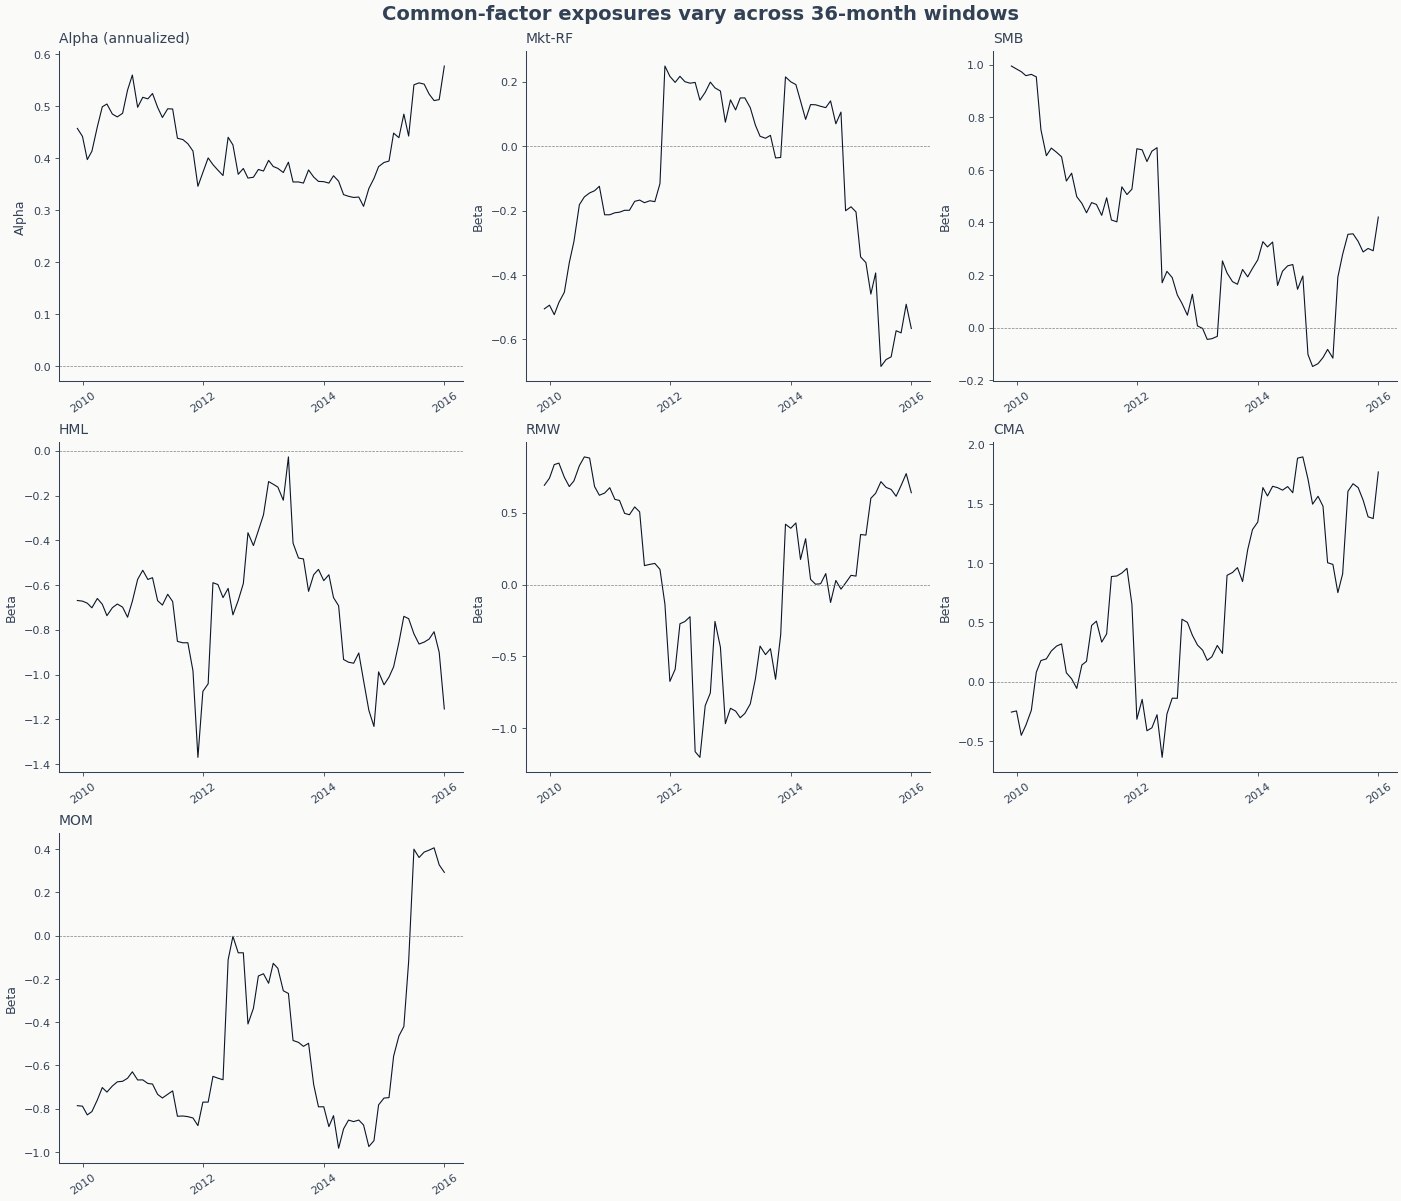

In [60]:
_rolling = compute_rolling_exposures(
    _strategy_rets, _factors, model="ff5_mom", window=36, dollar_neutral=True
)
fig_roll = plot_rolling_exposures(
    _rolling, title="Common-factor exposures vary across 36-month windows"
)
for _ax in fig_roll.axes:
    _ax.xaxis.set_major_locator(mdates.YearLocator(2))
    _ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    _ax.tick_params(axis="x", rotation=35)
fig_roll.show()

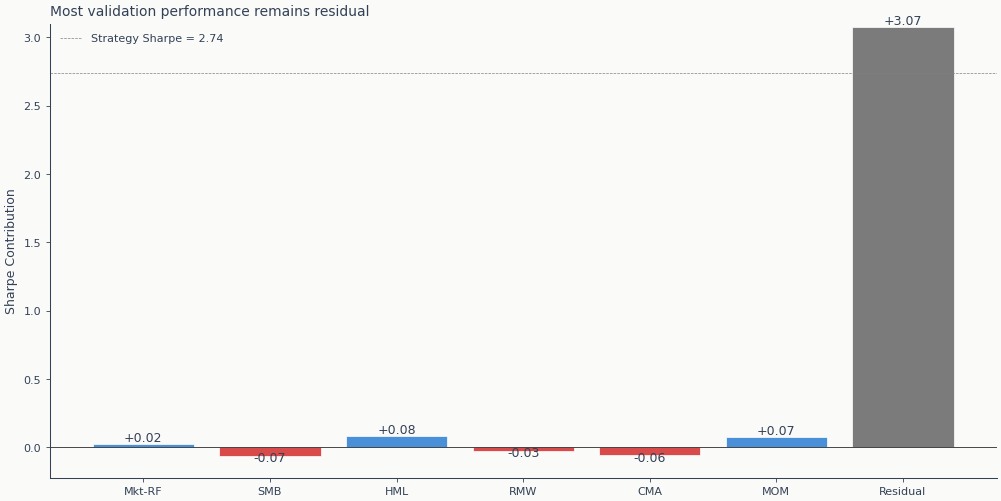

In [61]:
fig_attr = plot_attribution_waterfall(_reg, title="Most validation performance remains residual")
fig_attr.axes[0].set_ylim(top=3.1)
fig_attr.axes[0].legend(loc="upper left", frameon=False)
fig_attr.show()

In [62]:
_boot = compute_bootstrap_ci(
    _strategy_rets,
    _factors,
    model="ff5_mom",
    n_boot=1000,
    block_size=4,
    dollar_neutral=True,
    seed=SEED,
)

if _boot.get("n_boot", 0) > 0:
    print(f"Bootstrap CIs (n={_boot['n_boot']}, block=4 months):")
    print(f"  Alpha (ann.): [{_boot['alpha_ann_lo']:+.1%}, {_boot['alpha_ann_hi']:+.1%}]")
    for factor in _reg["factor_columns"]:
        key_lo = f"{factor}_lo"
        key_hi = f"{factor}_hi"
        if key_lo in _boot:
            print(f"  {factor:8s}: [{_boot[key_lo]:+.4f}, {_boot[key_hi]:+.4f}]")

Bootstrap CIs (n=1000, block=4 months):
  Alpha (ann.): [+33.6%, +59.1%]
  Mkt-RF  : [-0.4131, +0.0837]
  SMB     : [-0.0595, +0.9994]
  HML     : [-1.0097, +0.0663]
  RMW     : [-0.6167, +0.8666]
  CMA     : [-0.5665, +1.2503]
  MOM     : [-0.8667, +0.0911]


### Placebo benchmark: random dollar-neutral portfolios

To separate signal-driven factor exposure from universe-driven
exposure, we draw 500 random dollar-neutral portfolios from the same
universe and compare the strategy's factor loadings to the random
distribution.

In [63]:
_prices_path = CASE_DIR / "labels" / "prices.parquet"
if _prices_path.exists():
    _returns = (
        pl.scan_parquet(_prices_path)
        .select(
            pl.col("timestamp").cast(pl.Date),
            pl.col("symbol").cast(pl.String),
            "ret",
        )
        .filter(
            pl.col("timestamp").is_between(_strategy_rets.index.min(), _strategy_rets.index.max())
        )
        .collect()
    )
    _fc_wide = _returns.pivot(on="symbol", index="timestamp", values="ret").to_pandas()
    _fc_wide = _fc_wide.set_index("timestamp")
    _fc_wide.index = pd.to_datetime(_fc_wide.index)

    _placebo = run_placebo_benchmark(
        _fc_wide,
        _factors,
        n_sims=500,
        top_k=50,
        model="ff5_mom",
        seed=SEED,
        periods_per_year=PERIODS_PER_YEAR,
    )

In [64]:
if _prices_path.exists():
    if _placebo["n_sims"] > 0:
        print(
            f"Placebo benchmark ({_placebo['n_sims']} random dollar-neutral portfolios, top_k=50):"
        )
        print(
            f"  Random Mkt-RF: {_placebo['Mkt-RF_mean']:+.3f} "
            f"[{_placebo['Mkt-RF_p5']:+.3f}, {_placebo['Mkt-RF_p95']:+.3f}]"
        )
        print(
            f"  Random SMB:    {_placebo['SMB_mean']:+.3f} "
            f"[{_placebo['SMB_p5']:+.3f}, {_placebo['SMB_p95']:+.3f}]"
        )
        print(
            f"  Random HML:    {_placebo['HML_mean']:+.3f} "
            f"[{_placebo['HML_p5']:+.3f}, {_placebo['HML_p95']:+.3f}]"
        )
        print(
            f"  Random alpha (ann): {_placebo['alpha_ann_mean']:+.1%} "
            f"± {_placebo['alpha_ann_std']:.1%}"
        )
        print(f"  Random R²:     {_placebo['r_squared_mean']:.3f}")
        print()

        for factor in ["Mkt-RF", "SMB", "HML"]:
            strat_beta = _reg["betas"].get(factor, 0)
            p5 = _placebo[f"{factor}_p5"]
            p95 = _placebo[f"{factor}_p95"]
            inside = "within" if p5 <= strat_beta <= p95 else "OUTSIDE"
            print(
                f"  Strategy {factor}: {strat_beta:+.3f} - {inside} random 90% CI "
                f"[{p5:+.3f}, {p95:+.3f}]"
            )
else:
    _placebo = {"n_sims": 0}
    print("Prices parquet not found - placebo benchmark skipped.")

Placebo benchmark (500 random dollar-neutral portfolios, top_k=50):
  Random Mkt-RF: -0.018 [-0.557, +0.531]
  Random SMB:    +0.003 [-0.896, +0.927]
  Random HML:    +0.084 [-1.170, +1.346]
  Random alpha (ann): -0.2% ± 3.5%
  Random R²:     0.068

  Strategy Mkt-RF: -0.180 - within random 90% CI [-0.557, +0.531]
  Strategy SMB: +0.474 - within random 90% CI [-0.896, +0.927]
  Strategy HML: -0.611 - within random 90% CI [-1.170, +1.346]


**Layer 1 / Layer 2 reading.** Information ratio against the EW
universe is positive in the validation window with the Layer-1
tracking-error read tightening the picture. The Layer-2 FF5+MOM
attribution explains about 20% of monthly return variation. HML and
momentum coefficients are significant at 5%, while the HML loading still
lies inside the random-portfolio interval; residual Sharpe exceeds the gross
figure. The placebo-benchmark
comparison answers whether the factor loadings are signal- or
universe-driven: any strategy beta that sits **outside** the random
90% CI is selection-driven; a beta **inside** the CI reflects
universe composition more than ML stock picking. Together with §5's
extended cost grid, this is the deployment-relevant edge profile:
common factors do not explain away the result, while implementation
cost remains the binding concern.

## §8 Strategy tear sheet

The diagnostic library renders the rank-1 lineage's tear sheet
directly from on-disk artifacts. This case study runs through the
vectorized backtester, which emits `daily_returns.parquet`,
`weights.parquet`, and `spec.json` but **no** `trades.parquet`:
the source dataset (US firm characteristics) carries portfolio
returns directly without an underlying fill stream. The bridge layer
that builds a `BacktestProfile` for the standalone tear-sheet HTML
requires per-trade fills, so the tear sheet is intentionally
unavailable here. Per strategy-analysis convention we do not synthesize trades.

What the tear sheet would have shown is split across other sections:

- **Returns and equity:** §3 forest plot, §3 equity overlay, §3
  sub-period decomposition.
- **Risk panels:** §4 drawdown analysis, §4b inline returns
  distribution / drawdown underwater / rolling Sharpe / tail risk.
- **Holdout closure:** §6 paired-bootstrap CI.
- **Factor attribution:** §7 FF5+MOM regression and rolling
  exposures.
- **ML / IC diagnostics:** §3 forest plot summarises the prediction-
  side IC with HAC CI; the trade-conditional alignment view a tear
  sheet would carry is unavailable for the same fill-stream reason.

This is a case-study-shape note, not a result. Datasets that carry
only portfolio returns will always trade tear-sheet richness for
pipeline simplicity; the diagnostic surfaces above carry the same
evidence in modular form.

In [65]:
backtest_dir = CASE_DIR / "run_log" / "backtest" / TOP_HASH
ho_dir = CASE_DIR / "run_log" / "backtest" / HO_HASH
trades_present = (backtest_dir / "trades.parquet").exists()
ho_trades_present = (ho_dir / "trades.parquet").exists()
print(f"Validation backtest_dir: {display_path(backtest_dir)}")
print(f"  trades.parquet present:   {trades_present}")
print(f"  daily_returns.parquet:    {(backtest_dir / 'daily_returns.parquet').exists()}")
print(f"  weights.parquet:          {(backtest_dir / 'weights.parquet').exists()}")
print()
print(f"Holdout backtest_dir:    {display_path(ho_dir)}")
print(f"  trades.parquet present:   {ho_trades_present}")
print()

if trades_present:
    bench_series = bench_val.rename({"benchmark": "ew_return"})["ew_return"].to_numpy()
    meta = BacktestReportMetadata(
        title="US Firm Characteristics - Rank-1 Lineage",
        strategy_name=f"{RANK1_FAMILY}/{RANK1_CONFIG} - {RANK1_LABEL}",
        universe=("~2,500 US firms (filters: min_price=$5, min_ADV=$1M, ex-financials/REITs/ADRs)"),
        benchmark_name="EW universe (validation)",
        evaluation_window=f"{aligned['ts'].min()} to {aligned['ts'].max()}",
        calendar=setup["evaluation"].get("calendar") or "NYSE",
    )
    tear_path = OUTPUT_DIR / f"{CASE_STUDY}_tearsheet.html"
    html = generate_tearsheet_from_run_artifacts(
        backtest_dir,
        template="risk_manager",
        benchmark=bench_series,
        benchmark_name="EW universe (validation)",
        calendar=setup["evaluation"].get("calendar") or "NYSE",
        report_metadata=meta,
        output_path=str(tear_path),
    )
    print(f"Tear sheet written to: {display_path(tear_path)}")
    print(f"HTML size: {len(html):,} bytes")
    tear_status = "rendered"
else:
    tear_status = "skipped_no_trades"

Validation backtest_dir: case_studies/us_firm_characteristics/run_log/backtest/b43559d60839
  trades.parquet present:   False
  daily_returns.parquet:    True
  weights.parquet:          True

Holdout backtest_dir:    case_studies/us_firm_characteristics/run_log/backtest/3d39bbd68481
  trades.parquet present:   False



## §9 Pre-Ch20 judgment & handoff

This section is the explicit hand-off point to Chapter 20. Numbers
below stay strictly inside us_firm_characteristics; cross-case-study
comparison is Ch20's lane.

In [66]:
op_profile = pl.DataFrame(
    [
        {"property": "Carrier", "value": f"{RANK1_FAMILY}/{RANK1_CONFIG}/{RANK1_LABEL}"},
        {"property": "Signal", "value": "equal_weight_top_k, 50 names per leg"},
        {"property": "Allocation", "value": "equal_weight"},
        {"property": "Trading cadence", "value": setup["decision"]["cadence"]},
        {"property": "Execution", "value": "next bar open"},
        {"property": "Registered cost", "value": "12.5 bps per leg"},
        {"property": "Validation Sharpe", "value": f"{val_full['sharpe']:.3f}"},
        {"property": "Holdout Sharpe", "value": f"{ho_full['sharpe']:.3f}"},
        {"property": "Validation max drawdown", "value": f"{val_full['max_drawdown']:.1%}"},
    ]
)
print("Operating profile (us_firm_characteristics, validation window):")
print(op_profile)
print()
print(
    f"Sharpe: {_fmt_ci(val_full['sharpe'], val_full['sharpe_ci95_lo'], val_full['sharpe_ci95_hi'])}"
)
print(f"Info ratio (vs EW val): {_fmt_ci(getattr(metrics, 'information_ratio', None), None, None)}")
print(f"Max drawdown: {val_full['max_drawdown']:.3f}")

Operating profile (us_firm_characteristics, validation window):
shape: (9, 2)
┌─────────────────────────┬─────────────────────────────────┐
│ property                ┆ value                           │
│ ---                     ┆ ---                             │
│ str                     ┆ str                             │
╞═════════════════════════╪═════════════════════════════════╡
│ Carrier                 ┆ gbm/default_huber/fwd_ret_1m_w… │
│ Signal                  ┆ equal_weight_top_k, 50 names p… │
│ Allocation              ┆ equal_weight                    │
│ Trading cadence         ┆ monthly_month_end               │
│ Execution               ┆ next bar open                   │
│ Registered cost         ┆ 12.5 bps per leg                │
│ Validation Sharpe       ┆ 2.738                           │
│ Holdout Sharpe          ┆ 2.613                           │
│ Validation max drawdown ┆ -10.1%                          │
└─────────────────────────┴───────────────────────────

In [67]:
gate1_status = gate1_validation_sharpe_geq_zero(val_full["sharpe_ci95_lo"])
_gate1_phrase = {
    "pass": "≥ 0 (passes)",
    "fail": "< 0 (fails)",
    "no_data": "CI unavailable",
}[gate1_status]
gate1_evidence = (
    f"Sharpe CI lower bound = {_fmt(val_full['sharpe_ci95_lo'], '.3f')} ({_gate1_phrase})"
)
gate2_ci_status = ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"])
gate2_status = gate2_holdout_diff_not_excludes_zero_negatively(gate2_ci_status, he["sharpe_diff"])
gate2_evidence = (
    f"Holdout strategy vs EW diff-Sharpe = "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])} "
    f"({gate2_ci_status})"
)

print("Kill-condition gates:")
print(f"  [{fmt_gate(gate1_status)}] Validation Sharpe CI lower bound ≥ 0:")
print(f"      {gate1_evidence}")
print(f"  [{fmt_gate(gate2_status)}] Holdout strategy CI does not exclude zero negatively:")
print(f"      {gate2_evidence}")

Kill-condition gates:
  [PASS] Validation Sharpe CI lower bound ≥ 0:
      Sharpe CI lower bound = 2.236 (≥ 0 (passes))
  [PASS] Holdout strategy CI does not exclude zero negatively:
      Holdout strategy vs EW diff-Sharpe = 1.379 [-2.204, 4.948] (straddles_zero)


**What this analysis does not say.** The validation window covers
110 monthly returns through 2015 on quarterly-updated firm
characteristics; the 2016 holdout is 12 monthly observations,
short enough that paired CIs span an order of magnitude. The
setup-primary label `fwd_ret_1m` is the EW benchmark and the
prose-reference label; the registered rank-1 trains on the
winsorized variant `fwd_ret_1m_win`, so the numerical conclusions
reported here pertain to that winsorized variant. The
winsorization clips the extreme tails of the regression target but
the strategy's executed positions are evaluated on un-winsorized
realized returns. The §5 micro-cap-realistic cost grid surfaces
implementation friction the gross headline does not capture; a
capacity-constrained deployment would shrink the long-short spread
meaningfully relative to the validation profile. The dollar-neutral
(long-short) construction assumes borrow availability for the short
leg at the era-dependent rate noted in `setup.yaml`. Selection
adjustment is reported in §3 through the family-cohort DSR variants
(raw / MP / ER) and the PBO statistic from cohort_metrics.

**Forward pointer to Ch20.** This case study contributes the US
equity / monthly / cross-sectional-firm-characteristic datapoint to
Ch20 nb01's rank-1-Sharpe + holdout-decay aggregation; the §6 decay
magnitude and the §6 strategy-vs-EW holdout read feed Ch20 nb05's
decay-classification table; the §5 micro-cap-realistic cost grid
contributes the capacity-binding-constraint exemplar to Ch20 nb04's
cost-survival comparison.